

大家加油🌟


## 載入資料集與套件
dataset放在我的雲端中，每次都要重新access

In [ ]:
!pip install gdown
!gdown 1FXUJHPqqtCNjG2pABPz-vFnVeGgxz4kT

Downloading...
From (original): https://drive.google.com/uc?id=1FXUJHPqqtCNjG2pABPz-vFnVeGgxz4kT
From (redirected): https://drive.google.com/uc?id=1FXUJHPqqtCNjG2pABPz-vFnVeGgxz4kT&confirm=t&uuid=dae8d395-fac8-4b69-9abf-540125d45620
To: /content/datasets.zip
100% 746M/746M [00:08<00:00, 88.2MB/s]


In [ ]:
!unzip datasets.zip -d data/

Archive:  datasets.zip
   creating: data/kkbox_datasets/
  inflating: data/kkbox_datasets/songs.csv  
  inflating: data/__MACOSX/kkbox_datasets/._songs.csv  
  inflating: data/kkbox_datasets/test.csv  
  inflating: data/__MACOSX/kkbox_datasets/._test.csv  
  inflating: data/kkbox_datasets/members.csv  
  inflating: data/__MACOSX/kkbox_datasets/._members.csv  
  inflating: data/kkbox_datasets/.ipynb  
  inflating: data/__MACOSX/kkbox_datasets/._.ipynb  
  inflating: data/kkbox_datasets/dataset_summary.txt  
  inflating: data/__MACOSX/kkbox_datasets/._dataset_summary.txt  
  inflating: data/kkbox_datasets/train.csv  
  inflating: data/__MACOSX/kkbox_datasets/._train.csv  
  inflating: data/kkbox_datasets/sample_submission.csv  
  inflating: data/__MACOSX/kkbox_datasets/._sample_submission.csv  
  inflating: data/kkbox_datasets/song_extra_info.csv  
  inflating: data/__MACOSX/kkbox_datasets/._song_extra_info.csv  


In [ ]:
import os
print("包含以下資料：", os.listdir("/content/data/kkbox_datasets"))

包含以下資料： ['sample_submission.csv', 'dataset_summary.txt', 'train.csv', 'song_extra_info.csv', 'members.csv', 'test.csv', '.ipynb', 'songs.csv']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [ ]:
#讀取資料
members = pd.read_csv("/content/data/kkbox_datasets/members.csv")
songs = pd.read_csv("/content/data/kkbox_datasets/songs.csv")
song_extra = pd.read_csv("/content/data/kkbox_datasets/song_extra_info.csv")
train = pd.read_csv("/content/data/kkbox_datasets/train.csv")
test = pd.read_csv("/content/data/kkbox_datasets/test.csv")
sample_submission = pd.read_csv("/content/data/kkbox_datasets/sample_submission.csv")

##載入額外資料

In [ ]:
# 安裝 gdown
!pip -q install -U gdown

import os, gdown

DATA_DIR = "/content/data/project_preprocess"
os.makedirs(DATA_DIR, exist_ok=True)

# ✅ 正確對應（已確認）
files = {
    "artist_table.csv": "13-N6bK8RSACVQmqbwEyrGqZZvCdjQqry",
    "song_merge.csv": "1QD_UZZfLf8HCFQ-T6AgEg21O0zC5jsHe",
    "wikidata_isrc_matched_en_by_isrc.csv": "1XaLe-HmxuUaA0leKd7tT-i7h_b-mugeH",
}

for fname, fid in files.items():
    out_path = os.path.join(DATA_DIR, fname)
    url = f"https://drive.google.com/uc?id={fid}"
    gdown.download(
        url,
        out_path,
        quiet=False,
        fuzzy=True
    )

print("✅ 下載完成：", os.listdir(DATA_DIR))


Downloading...
From: https://drive.google.com/uc?id=13-N6bK8RSACVQmqbwEyrGqZZvCdjQqry
To: /content/data/project_preprocess/artist_table.csv
100%|██████████| 12.7M/12.7M [00:00<00:00, 59.6MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1QD_UZZfLf8HCFQ-T6AgEg21O0zC5jsHe
From (redirected): https://drive.google.com/uc?id=1QD_UZZfLf8HCFQ-T6AgEg21O0zC5jsHe&confirm=t&uuid=c4bfbc76-8ef8-4a11-b633-dae2f9e0c0c4
To: /content/data/project_preprocess/song_merge.csv
100%|██████████| 2.70G/2.70G [00:31<00:00, 85.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XaLe-HmxuUaA0leKd7tT-i7h_b-mugeH
To: /content/data/project_preprocess/wikidata_isrc_matched_en_by_isrc.csv
100%|██████████| 781k/781k [00:00<00:00, 59.4MB/s]

✅ 下載完成： ['artist_table.csv', 'wikidata_isrc_matched_en_by_isrc.csv', 'song_merge.csv']


In [ ]:
import pandas as pd
from IPython.display import display

DATA_DIR = "/content/data/project_preprocess"

In [ ]:
artist_table = pd.read_csv(
    f"{DATA_DIR}/artist_table.csv",
    encoding="utf-8-sig"
)

print("artist_table rows:", len(artist_table))

# 快速 sanity check（可留可刪）
display(artist_table.head(3))


artist_table rows: 222363


,artist_id,artist_name,artist_popularity,artist_popularity_log,composer_diff_ratio,lyricist_diff_ratio
0,1,"2 THE EXTREME,Master Chief & iLLest Game,,52\...",1,0.693147,1.0,0.0
1,2,"2 THE EXTREME,Master Chief & iLLest Game,,52\...",1,0.693147,1.0,0.0
2,3,!Conz,1,0.693147,0.0,0.0


In [ ]:
song_merge = pd.read_csv(
    f"{DATA_DIR}/song_merge.csv",
    encoding="utf-8-sig"
)
print("song_merge rows:", len(song_merge))
display(song_merge.head(3))

In [ ]:
wd_by_isrc = pd.read_csv(
    f"{DATA_DIR}/wikidata_isrc_matched_en_by_isrc.csv",
    encoding="utf-8-sig"
)
print("wikidata_isrc rows:", len(wd_by_isrc))
display(wd_by_isrc.head(3))

## 資料前處理

### member.csv

In [ ]:
# 檢查 bd 的分佈
print(members['bd'].value_counts().sort_index())

# 看看 bd=0 佔了多少比例
zeros_count = (members['bd'] == 0).sum()
total_count = len(members)
print(f"年齡為 0 的比例: {zeros_count / total_count * 100:.2f}%")

# 觀察年齡性別都正常的用戶比例 complete_members
complete_members = members[
    (members['bd'] >= 10) &
    (members['bd'] <= 80) &
    (members['gender'].notna())
].copy()

print(f"資料完整用戶數 {len(complete_members)}")

bd
-43          1
-38          1
 0       19932
 2           1
 3           1
         ...  
 131         1
 144         1
 931         1
 1030        1
 1051        1
Name: count, Length: 95, dtype: int64
年齡為 0 的比例: 57.94%
資料完整用戶數 14012


In [ ]:
# 轉換後，msno_id 會變成 0 到 N 的整數，記憶體佔用極小
msno_encoder = LabelEncoder()
complete_members['msno_id'] = msno_encoder.fit_transform(complete_members['msno'])
complete_members = complete_members.drop(columns = ['msno'])
print("msno_id處理完成")
complete_members = complete_members.reset_index(drop=True) # drop=True把舊的index(5, 10...) 直接丟掉
print("重設索引完成！")
print(complete_members.head())

#存對照表
with open('msno_encoder.pkl', 'wb') as f:
    pickle.dump(msno_encoder, f)

print("Encoder 已儲存為 msno_encoder.pkl")

# 查看轉換表前5項
mapping_table = pd.DataFrame({
    'msno_id': range(len(msno_encoder.classes_)),       # 0, 1, 2, ...
    'original_msno': msno_encoder.classes_              # 對應的原始亂碼
})
print(mapping_table.head(5))

msno_id處理完成
重設索引完成！
   city  bd  gender  registered_via  registration_init_time  expiration_date  \
0    13  43  female               9                20120703         20171006   
1    12  28    male               9                20060531         20170816   
2    15  33  female               3                20150915         20171019   
3    13  20    male               3                20140410         20170427   
4    13  30    male               9                20070330         20170612   

   msno_id  
0    13929  
1     4041  
2     6392  
3    13061  
4     3681  
Encoder 已儲存為 msno_encoder.pkl
   msno_id                                 original_msno
0        0  ++5wYjoMgQHoRuD3GbbvmphZbBBwymzv5Q4l8sywtuU=
1        1  ++AH7m/EQ4iKe6wSlfO/xXAJx50p+fCeTyF90GoE9Pg=
2        2  ++e+jsxuQ8UEnmW40od9Rq3rW7+wAum4wooXyZTKJpk=
3        3  ++xWL5Pbi2CpG4uUugigQahauM0J/sBIRloTNPBybIU=
4        4  +/UwoUi5+rNj/F6RO6gMrMhOy0oTzs90MWKVNZs4+Wg=


In [ ]:
# 處理年齡
# 1. 分箱處理
#  區間：0(未知), 1~12(兒童), 13~18(青少年), 19~25(大學/新鮮人), 26~35(青壯年), 36~50(壯年), 50+(中老年)
bins = [-1, 0, 12, 18,25,35,50,80]
labels = [0, 1, 2, 3, 4, 5, 6]
complete_members['bd_group'] = pd.cut(complete_members['bd'], bins=bins, labels=labels)

# 3. 縮減記憶體：轉為int8
complete_members['bd_group'] = complete_members['bd_group'].astype('int8')

del complete_members['bd']
print("年齡處理完成")
print(complete_members.head())

年齡處理完成
   city  gender  registered_via  registration_init_time  expiration_date  \
0    13  female               9                20120703         20171006   
1    12    male               9                20060531         20170816   
2    15  female               3                20150915         20171019   
3    13    male               3                20140410         20170427   
4    13    male               9                20070330         20170612   

   msno_id  bd_group  
0    13929         5  
1     4041         4  
2     6392         4  
3    13061         3  
4     3681         4  


In [ ]:
#性別
# 1. One-Hot Encoding
complete_members = pd.get_dummies(complete_members, columns=['gender'], prefix='gender', dtype='int8')

# 3. 移除 unknown 欄位，當male=0與female=0 代表 unknown)
# if 'gender_unknown' in members.columns:
#    members = members.drop(columns=['gender_unknown'])

print("性別處理完成")
print(complete_members.filter(like='gender_').head())

性別處理完成
   gender_female  gender_male
0              1            0
1              0            1
2              1            0
3              0            1
4              0            1


In [ ]:
#日期
# 1. 日期格式轉換
complete_members['registration_init_time'] = pd.to_datetime(complete_members['registration_init_time'], format='%Y%m%d', errors='coerce')
complete_members['expiration_date'] = pd.to_datetime(complete_members['expiration_date'], format='%Y%m%d', errors='coerce')

# 2. 提取註冊年份(無缺失值)
complete_members['registration_year'] = complete_members['registration_init_time'].dt.year.astype('int16')

# 3. 會員天數計算與分段
# 3.1 計算天數
complete_members['membership_days'] = (complete_members['expiration_date'] - complete_members['registration_init_time']).dt.days
complete_members['membership_days'] = complete_members['membership_days'].clip(lower=0).fillna(0)
print("最長會員天數：", complete_members['membership_days'].max())

# 3.2 分段區間 (針對 Max=5149 設計)
# 0-30天、30-180天、180-365天、365-730天、730-1825天(2-5年）、1825-3650天(5-10年)、3650天以上(10年以上)
bins = [0, 30, 180, 365, 730, 1825, 3650, np.inf]
labels = [0, 1, 2, 3, 4, 5, 6]  # 共 7 個區間

# 2.3 執行分箱
complete_members['membership_group'] = pd.cut(complete_members['membership_days'],
                                        bins=bins,
                                        labels=labels,
                                        include_lowest=True).astype('int8')

#3. 移除原始日期欄位
complete_members = complete_members.drop(columns=['registration_init_time', 'expiration_date'])

print("註冊年份分佈 (前5名):")
print(complete_members['registration_year'].value_counts().head())
print("會員年資分組分佈:")
print(complete_members['membership_group'].value_counts().sort_index())

最長會員天數： 5149
註冊年份分佈 (前5名):
registration_year
2016    2036
2011    1904
2015    1859
2013    1444
2014    1369
Name: count, dtype: int64
會員年資分組分佈:
membership_group
0     883
1     339
2     725
3    1609
4    4183
5    4645
6    1628
Name: count, dtype: int64


In [ ]:
#處理city&註冊方式：確保型態是 int8 即可 (因為原始資料已經是數字)
complete_members['city'] = complete_members['city'].astype('int8')
complete_members['registered_via'] = complete_members['registered_via'].astype('int8')
print("city&註冊方式處理完成")
print(complete_members.head())

city&註冊方式處理完成
   city  registered_via  msno_id  bd_group  gender_female  gender_male  \
0    13               9    13929         5              1            0   
1    12               9     4041         4              0            1   
2    15               3     6392         4              1            0   
3    13               3    13061         3              0            1   
4    13               9     3681         4              0            1   

   registration_year  membership_days  membership_group  
0               2012             1921                 5  
1               2006             4095                 6  
2               2015              765                 4  
3               2014             1113                 4  
4               2007             3727                 6  


/tmp/ipython-input-3251161110.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_counts.index, y=city_counts.values, order=city_counts.index, palette="viridis")


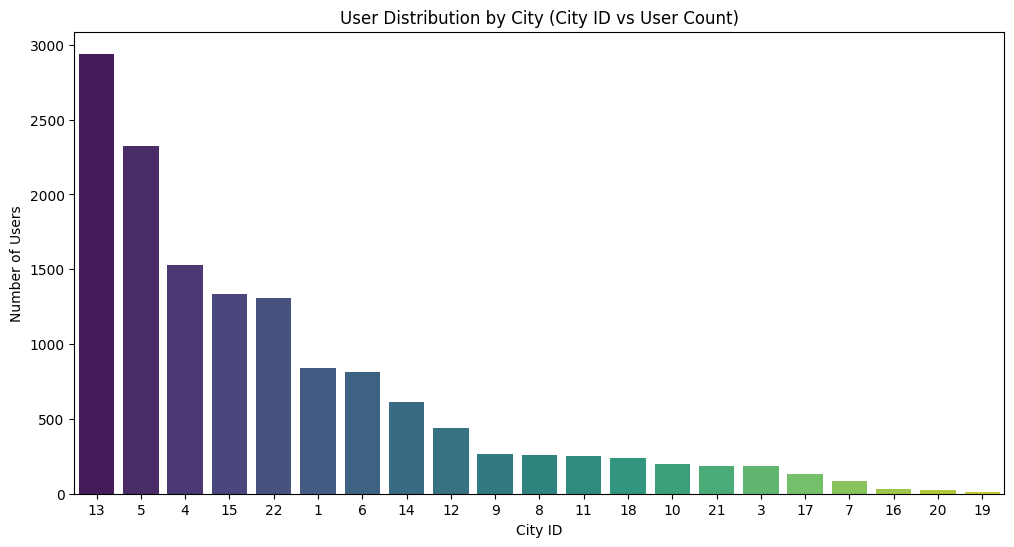

【城市人數統計 Top 5】
City 13: 2940 人 (21.0%)
City 5: 2323 人 (16.6%)
City 4: 1531 人 (10.9%)
City 15: 1336 人 (9.5%)
City 22: 1309 人 (9.3%)


In [ ]:
# 1. 統計與視覺化：計算每個城市的人數
city_counts = complete_members['city'].value_counts().sort_values(ascending=False)

# 畫圖
plt.figure(figsize=(12, 6))
sns.barplot(x=city_counts.index, y=city_counts.values, order=city_counts.index, palette="viridis")
plt.title("User Distribution by City (City ID vs User Count)")
plt.xlabel("City ID")
plt.ylabel("Number of Users")
plt.show()

# 印出前 5 大城市及其佔比
total_users = len(complete_members)
print("【城市人數統計 Top 5】")
for city, count in city_counts.head(5).items():
    print(f"City {city}: {count} 人 ({count/total_users:.1%})")

In [ ]:
# 2. 特徵工程：建立「城市等級」特徵，Count Encoding (直接用人數當特徵)
complete_members['city_count'] = complete_members['city'].map(city_counts)

# 3. 記憶體優化
complete_members['city_count'] = complete_members['city_count'].astype('int32')

print("城市人數特徵 (city_count) 建立完成！")
print(complete_members[['city', 'city_count']].head(10))

城市人數特徵 (city_count) 建立完成！
   city  city_count
0    13        2940
1    12         441
2    15        1336
3    13        2940
4    13        2940
5     5        2323
6     6         816
7     4        1531
8    11         253
9    15        1336


### song_extra_info.csv

In [ ]:
from sklearn.preprocessing import LabelEncoder
import pickle

print("********____song_extra_csv_____********** ")
num_song_extra_rows = song_extra.shape[0]
print("song_extra共幾列: ",num_song_extra_rows)
num_nan_id = song_extra['song_id'].isna().sum()
print("song_extra 的 id 中 NAN 的數量: ",num_nan_id)
num_nan_name = song_extra['name'].isna().sum()
print("song_extra 的 name 中 NAN 的數量: ",num_nan_name)
num_nan_isrc = song_extra['isrc'].isna().sum()
print("song_extra 的 isrc 中 NAN 的數量: ",num_nan_isrc)
print(" ")
print(song_extra.head(5))
print(" ")

#1 將song_extra的song_id亂碼變成整數
print("*1.將song_extra的song_id亂碼變成整數*")
print(" ")
print("********____song_extra_csv_1_____********** ")
song_extra_copy = song_extra.copy() #做一份副本，不會動到原本的 song_extra
song_extra_encoder = LabelEncoder()
song_extra_copy['song_id_new'] = song_extra_encoder.fit_transform(song_extra_copy['song_id'])

with open('song_encoder.pkl', 'wb') as f:
    pickle.dump(song_extra_encoder, f)  #把 Encoder 物件存進檔案

song_extra_copy = song_extra_copy.drop(columns = ['song_id'])
num_nan_id_new = song_extra_copy['song_id_new'].isna().sum()
num_nan_isrc = song_extra_copy['isrc'].isna().sum()
num_song_extra_copy_rows = song_extra_copy.shape[0]
print("song_extra_copy 的 song_id_new 中 NaN 的數量：",num_nan_id_new )
print("song_extra_copy共幾列: ",num_song_extra_copy_rows)
print("song_extra_copy 的 isrc 中 NaN 的數量：", num_nan_isrc)
num_nan_name = song_extra_copy['name'].isna().sum()
print("song_extra_copy 的 name 中 NaN 的數量：", num_nan_name)
print(" ")
print(song_extra_copy.head(5))
print(" ")

#2 製作song_mapping_table
print("2.建立old song id與new song id的對照表格")
print(" ")
print("********____song_mapping_table_____********** ")
mapping_table_song = pd.DataFrame({
    'song_id_new': range(len(song_extra_encoder.classes_)),       # 0, 1, 2, ...
    'original_song_id': song_extra_encoder.classes_              # 對應的原始亂碼
})
num_mapping_table_rows = mapping_table_song.shape[0]
print("table共幾列: ",num_mapping_table_rows)
print("")
print(mapping_table_song.head(5))


********____song_extra_csv_____********** 
song_extra共幾列:  2295971
song_extra 的 id 中 NAN 的數量:  0
song_extra 的 name 中 NAN 的數量:  3
song_extra 的 isrc 中 NAN 的數量:  136548
 
                                        song_id             name          isrc
0  LP7pLJoJFBvyuUwvu+oLzjT+bI+UeBPURCecJsX1jjs=               我們  TWUM71200043
1  ClazTFnk6r0Bnuie44bocdNMM3rdlrq0bCGAsGUWcHE=  Let Me Love You  QMZSY1600015
2  u2ja/bZE3zhCGxvbbOB3zOoUjx27u40cf5g09UXMoKQ=              原諒我  TWA530887303
3  92Fqsy0+p6+RHe2EoLKjHahORHR1Kq1TBJoClW9v+Ts=          Classic  USSM11301446
4  0QFmz/+rJy1Q56C1DuYqT9hKKqi5TUqx0sN0IwvoHrw=             愛投羅網  TWA471306001
 
*1.將song_extra的song_id亂碼變成整數*
 
********____song_extra_csv_1_____********** 
song_extra_copy 的 song_id_new 中 NaN 的數量： 0
song_extra_copy共幾列:  2295971
song_extra_copy 的 isrc 中 NaN 的數量： 136548
song_extra_copy 的 name 中 NaN 的數量： 3
 
              name          isrc  song_id_new
0               我們  TWUM71200043       841197
1  Let Me Love You  QMZSY1600015    

### songs.csv

In [ ]:
#原版songs的資料細節
print("********____song_csv_____********** ")
num_song_rows = songs.shape[0]
print("songs共幾列: ",num_song_rows)
num_nan_id = songs['song_id'].isna().sum()
print("songs 的 id 中 NAN 的數量: ",num_nan_id)
num_nan_length = songs['song_length'].isna().sum()
print("songs 的 length 中 NAN 的數量: ",num_nan_length)
num_nan_genre = songs['genre_ids'].isna().sum()
print("songs 的 genre 中 NAN 的數量: ",num_nan_genre)
num_nan_artist = songs['artist_name'].isna().sum()
print("songs 的 artist 中 NAN 的數量: ",num_nan_artist)
num_nan_composer = songs['composer'].isna().sum()
print("songs 的 composer 中 NAN 的數量: ",num_nan_composer)
num_nan_lyricist = songs['lyricist'].isna().sum()
print("songs 的 lyricist 中 NAN 的數量: ",num_nan_lyricist)
num_nan_language = songs['language'].isna().sum()
print("songs 的 language 中 NAN 的數量: ",num_nan_language)
print(" ")
print(songs.head(5))
print(" ")

#1.建立songs_copy 以table改掉song_id
print("1.建立songs_copy 以table改掉song_id")
songs_copy = songs.merge(
    mapping_table_song,
    left_on='song_id',
    right_on='original_song_id',
    how='left'
)
songs_copy = songs_copy.drop(columns=['song_id', 'original_song_id']) # 刪掉舊的欄位

num_nan_song_id_new = songs_copy['song_id_new'].isna().sum()
print("songs_copy 的 song_id_new 中 NAN 的數量: ",num_nan_song_id_new)
print(" ")
print("********____songs_copy_____********** ")
print(songs_copy.head(5))

********____song_csv_____********** 
songs共幾列:  2296320
songs 的 id 中 NAN 的數量:  0
songs 的 length 中 NAN 的數量:  0
songs 的 genre 中 NAN 的數量:  94116
songs 的 artist 中 NAN 的數量:  0
songs 的 composer 中 NAN 的數量:  1071358
songs 的 lyricist 中 NAN 的數量:  1945306
songs 的 language 中 NAN 的數量:  1
 
                                        song_id  song_length genre_ids  \
0  CXoTN1eb7AI+DntdU1vbcwGRV4SCIDxZu+YD8JP8r4E=       247640       465   
1  o0kFgae9QtnYgRkVPqLJwa05zIhRlUjfF7O1tDw0ZDU=       197328       444   
2  DwVvVurfpuz+XPuFvucclVQEyPqcpUkHR0ne1RQzPs0=       231781       465   
3  dKMBWoZyScdxSkihKG+Vf47nc18N9q4m58+b4e7dSSE=       273554       465   
4  W3bqWd3T+VeHFzHAUfARgW9AvVRaF4N5Yzm4Mr6Eo/o=       140329       726   

        artist_name                            composer     lyricist  language  
0  張信哲 (Jeff Chang)                                  董貞          何啟弘       3.0  
1         BLACKPINK  TEDDY|  FUTURE BOUNCE|  Bekuh BOOM        TEDDY      31.0  
2      SUPER JUNIOR               

把songs和song_extra合併，使資料較完整

In [ ]:
#1.將整理過後的songs_copy和song_extra_copy以song_id_new進行合併
print("1.將整理過後的songs_copy和song_extra_copy以song_id_new進行合併")

song_merge = songs_copy.merge(song_extra_copy, on="song_id_new", how="left") #合併

#合併後的資料細節
num_song_merge_rows = song_merge.shape[0]
print("song_merge共幾列: ",num_song_merge_rows)
num_nan_id_new = song_merge['song_id_new'].isna().sum()
print("song_merge 的 new id 中 NAN 的數量: ",num_nan_id_new)
num_nan_length = song_merge['song_length'].isna().sum()
print("song_merge 的 length 中 NAN 的數量: ",num_nan_length)
num_nan_genre = song_merge['genre_ids'].isna().sum()
print("song_merge 的 genre 中 NAN 的數量: ",num_nan_genre)
num_nan_artist = song_merge['artist_name'].isna().sum()
print("song_merge 的 artist 中 NAN 的數量: ",num_nan_artist)
num_nan_composer = song_merge['composer'].isna().sum()
print("song_merge 的 composer 中 NAN 的數量: ",num_nan_composer)
num_nan_lyricist = song_merge['lyricist'].isna().sum()
print("song_merge 的 lyricist 中 NAN 的數量: ",num_nan_lyricist)
num_nan_language = song_merge['language'].isna().sum()
print("song_merge 的 language 中 NAN 的數量: ",num_nan_language)
num_nan_name = song_merge['name'].isna().sum()
print("song_merge 的 name 中 NAN 的數量: ",num_nan_name)
num_nan_isrc = song_merge['isrc'].isna().sum()
print("song_merge 的 isrc 中 NAN 的數量: ",num_nan_isrc)
print(" ")
print("********____song_merge_____********** ")
print(song_merge.head(5))



1.將整理過後的songs_copy和song_extra_copy以song_id_new進行合併
song_merge共幾列:  2296320
song_merge 的 new id 中 NAN 的數量:  898
song_merge 的 length 中 NAN 的數量:  0
song_merge 的 genre 中 NAN 的數量:  94116
song_merge 的 artist 中 NAN 的數量:  0
song_merge 的 composer 中 NAN 的數量:  1071358
song_merge 的 lyricist 中 NAN 的數量:  1945306
song_merge 的 language 中 NAN 的數量:  1
song_merge 的 name 中 NAN 的數量:  901
song_merge 的 isrc 中 NAN 的數量:  137428
 
********____song_merge_____********** 
   song_length genre_ids       artist_name  \
0       247640       465  張信哲 (Jeff Chang)   
1       197328       444         BLACKPINK   
2       231781       465      SUPER JUNIOR   
3       273554       465             S.H.E   
4       140329       726              貴族精選   

                             composer     lyricist  language  song_id_new  \
0                                  董貞          何啟弘       3.0     523020.0   
1  TEDDY|  FUTURE BOUNCE|  Bekuh BOOM        TEDDY      31.0    1867000.0   
2                                 NaN       

### NAN處理

In [ ]:
#1.建立缺失指標(有沒有值，NAN->0)
print("1.建立缺失指標(有沒有值，NAN->0)")
song_merge['has_isrc'] = song_merge['isrc'].notna().astype(int)
song_merge['has_genre'] = song_merge['genre_ids'].notna().astype(int)
song_merge['has_composer'] = song_merge['composer'].notna().astype(int)
song_merge['has_lyricist'] = song_merge['lyricist'].notna().astype(int)
song_merge['has_name'] = song_merge['name'].notna().astype(int)
song_merge['has_song_extra'] = song_merge['song_id_new'].notna().astype(int)
print(" ")
print("********____song_merge_____********** ")
print(song_merge.head(5))

1.建立缺失指標(有沒有值，NAN->0)
 
********____song_merge_____********** 
   song_length genre_ids       artist_name  \
0       247640       465  張信哲 (Jeff Chang)   
1       197328       444         BLACKPINK   
2       231781       465      SUPER JUNIOR   
3       273554       465             S.H.E   
4       140329       726              貴族精選   

                             composer     lyricist  language  song_id_new  \
0                                  董貞          何啟弘       3.0     523020.0   
1  TEDDY|  FUTURE BOUNCE|  Bekuh BOOM        TEDDY      31.0    1867000.0   
2                                 NaN          NaN      31.0     572864.0   
3                                 湯小康          徐世珍       3.0    1483642.0   
4                         Traditional  Traditional      52.0    1223703.0   

                     name          isrc  has_isrc  has_genre  has_composer  \
0                      焚情  TWB531410010         1          1             1   
1       PLAYING WITH FIRE           NaN  

In [ ]:
print("NAN補植")
print("song_length NAN-> 中位數")
#song_length NAN-> 中位數 (不補平均是因為平均可能被極端值拉的怪怪的)
song_merge['song_length'] = song_merge['song_length'].fillna(song_merge['song_length'].median())
print("genre_ids NAN-> unknown")
#genre_ids NAN-> unknown
song_merge['genre_ids'] = song_merge['genre_ids'].fillna("unknown")
print("artist_name NAN-> unknown")
#artist_name NAN-> unknown
song_merge['artist_name'] = song_merge['artist_name'].fillna("unknown")
print("composer NAN-> unknown")
#composer NAN-> unknown
song_merge['composer'] = song_merge['composer'].fillna("unknown")
print("lyricist NAN-> unknown")
#lyricist NAN-> unknown
song_merge['lyricist'] = song_merge['lyricist'].fillna("unknown")
print("language NAN-> 眾數")
#language NAN-> 眾數
song_merge['language'] = song_merge['language'].fillna(song_merge['language'].mode()[0])
print("name NAN-> unknown")
#name NAN-> unknown
song_merge['name'] = song_merge['name'].fillna("unknown")
print("isrc NAN-> none")
#isrc NAN-> none
song_merge['isrc'] = song_merge['isrc'].fillna("NONE")
print("song_id_new NAN-> -1")
#song_id_new NAN-> -1
song_merge['song_id_new'] = song_merge['song_id_new'].fillna(-1)
song_merge['song_id_new'] = song_merge['song_id_new'].astype(int) # float->int

#檢查 NaN 是否都處理乾淨
print(" ")
print("檢查 NaN 是否都處理乾淨")
song_merge.isna().sum()
print("剩下的NAN數量: ")
print(song_merge.isna().sum())

NAN補植
song_length NAN-> 中位數
genre_ids NAN-> unknown
artist_name NAN-> unknown
composer NAN-> unknown
lyricist NAN-> unknown
language NAN-> 眾數
name NAN-> unknown
isrc NAN-> none
song_id_new NAN-> -1
 
檢查 NaN 是否都處理乾淨
剩下的NAN數量: 
song_length       0
genre_ids         0
artist_name       0
composer          0
lyricist          0
language          0
song_id_new       0
name              0
isrc              0
has_isrc          0
has_genre         0
has_composer      0
has_lyricist      0
has_name          0
has_song_extra    0
dtype: int64


### 特徵工程

In [ ]:
print("====== song_length 最大/最小值（毫秒） ======")
print("min:", (song_merge['song_length'].min())/60000)
print("max:", (song_merge['song_length'].max())/60000)

====== song_length 最大/最小值（毫秒） ======
min: 0.0030833333333333333
max: 202.8975


In [ ]:
print("1.將length轉成分鐘")
#1.song_length是毫秒轉成分鐘
song_merge['length_min'] = song_merge['song_length'] / 60000
print("********____song_length_____********** ")
print(song_merge[['song_length', 'length_min']].head(5))
print(" ")


print("2.建立 length_bin（固定區間 0~1~2~3~4~5~300 分")
#2.建立 length_bin（固定區間 0~1~2~3~4~5~300 分
bins = [0, 1, 2, 3, 4, 5, 300]  # 最後放 300 避免 outlier 掉出去
labels = ['0-1', '1-2', '2-3', '3-4', '4-5', '5+']

song_merge['length_bin'] = pd.cut(
    song_merge['length_min'],
    bins=bins,
    labels=labels,
    right=False   # left-inclusive: [0,1)
)
print("********____length_bin_____********** ")
print(song_merge[['length_min', 'length_bin']].head(20))
print(" ")

print("====== 檢查 length_bin 是否有 NaN（應該為 0） ======")
print(song_merge['length_bin'].isna().sum())


1.將length轉成分鐘
********____song_length_____********** 
   song_length  length_min
0       247640    4.127333
1       197328    3.288800
2       231781    3.863017
3       273554    4.559233
4       140329    2.338817
 
2.建立 length_bin（固定區間 0~1~2~3~4~5~300 分
********____length_bin_____********** 
    length_min length_bin
0     4.127333        4-5
1     3.288800        3-4
2     3.863017        3-4
3     4.559233        4-5
4     2.338817        2-3
5     3.925333        3-4
6     3.770333        3-4
7     4.613217        4-5
8     3.810383        3-4
9     3.877150        3-4
10    4.542400        4-5
11    4.248000        4-5
12    3.014517        3-4
13    4.293367        4-5
14    4.711617        4-5
15    3.691967        3-4
16    3.319283        3-4
17    2.823833        2-3
18    6.233783         5+
19    4.100250        4-5
 
====== 檢查 length_bin 是否有 NaN（應該為 0） ======
0


In [ ]:
import re
import numpy as np

print("1. 使用更嚴謹的正規表達式檢查 ISRC 格式")

# 建立 regex pattern
isrc_pattern = re.compile(r'^[A-Z]{2}[A-Z0-9]{3}[0-9]{2}[0-9]{5}$')

def is_valid_isrc(x):
    if x == "NONE":
        return 0
    if not isinstance(x, str):
        return 0
    return 1 if isrc_pattern.match(x) else 0

# apply 到整個欄位
song_merge['has_valid_isrc'] = song_merge['isrc'].apply(is_valid_isrc)
print(" ")
print(song_merge[['isrc','has_valid_isrc']].head(10))
print("value counts:", song_merge['has_valid_isrc'].value_counts())
print(" ")

print("2. 從 ISRC 拆出 country / registrant / year / item_id")
# 先給預設值，避免不合法 ISRC 造成錯誤
song_merge['isrc_country'] = "UNK"      # unknown
song_merge['isrc_registrant'] = "UNK"
song_merge['isrc_year'] = "UNK"
song_merge['isrc_item_id'] = "UNK"
print(" ")

# 只對 has_valid_isrc == 1 的資料做 slicing
valid_mask = song_merge['has_valid_isrc'] == 1
valid_isrc = song_merge.loc[valid_mask, 'isrc']

song_merge.loc[valid_mask, 'isrc_country']    = valid_isrc.str[:2]
song_merge.loc[valid_mask, 'isrc_registrant'] = valid_isrc.str[2:5]
song_merge.loc[valid_mask, 'isrc_year']       = valid_isrc.str[5:7]
song_merge.loc[valid_mask, 'isrc_item_id']    = valid_isrc.str[7:]

print("********____ISRC_parse_sample_____********** ")
print(song_merge.loc[valid_mask,
                     ['isrc','isrc_country','isrc_registrant','isrc_year','isrc_item_id']
                    ].head(10))
print(" ")


1. 使用更嚴謹的正規表達式檢查 ISRC 格式
 
           isrc  has_valid_isrc
0  TWB531410010               1
1          NONE               0
2          NONE               0
3  TWC950206108               1
4          NONE               0
5          NONE               0
6  TWH951100012               1
7  TWA450582110               1
8  TWA531398021               1
9  GBARL1401580               1
value counts: has_valid_isrc
1    2158874
0     137446
Name: count, dtype: int64
 
2. 從 ISRC 拆出 country / registrant / year / item_id
 
********____ISRC_parse_sample_____********** 
            isrc isrc_country isrc_registrant isrc_year isrc_item_id
0   TWB531410010           TW             B53        14        10010
3   TWC950206108           TW             C95        02        06108
6   TWH951100012           TW             H95        11        00012
7   TWA450582110           TW             A45        05        82110
8   TWA531398021           TW             A53        13        98021
9   GBARL1401580         

In [ ]:
print("將年份換成完整西元年")
#將年份換成完整西元年
def convert_isrc_year(yy):
    if yy == "UNK":  # 無效 ISRC
        return np.nan
    yy_int = int(yy)
    if yy_int <= 25:
        return 2000 + yy_int
    else:
        return 1900 + yy_int
print(" ")

song_merge['isrc_year_full'] = song_merge['isrc_year'].apply(convert_isrc_year)
print("********____ISRC_year_full_____********** ")
print(song_merge[['isrc_year', 'isrc_year_full']].head(20))
print(" ")
print(song_merge['isrc_year_full'].describe())

將年份換成完整西元年
 
********____ISRC_year_full_____********** 
   isrc_year  isrc_year_full
0         14          2014.0
1        UNK             NaN
2        UNK             NaN
3         02          2002.0
4        UNK             NaN
5        UNK             NaN
6         11          2011.0
7         05          2005.0
8         13          2013.0
9         14          2014.0
10        16          2016.0
11        14          2014.0
12        14          2014.0
13        15          2015.0
14        15          2015.0
15        16          2016.0
16        15          2015.0
17        17          2017.0
18        12          2012.0
19        13          2013.0
 
count    2.158874e+06
mean     2.007573e+03
std      1.114605e+01
min      1.926000e+03
25%      2.004000e+03
50%      2.011000e+03
75%      2.015000e+03
max      2.025000e+03
Name: isrc_year_full, dtype: float64


In [ ]:
print("song_age = current_year - isrc_year_full")
#算出歌曲年紀
current_year = 2025
song_merge['song_age'] = current_year - song_merge['isrc_year_full']

print(song_merge[['isrc_year_full', 'song_age']].head(20))
print(song_merge['song_age'].describe())

song_age = current_year - isrc_year_full
    isrc_year_full  song_age
0           2014.0      11.0
1              NaN       NaN
2              NaN       NaN
3           2002.0      23.0
4              NaN       NaN
5              NaN       NaN
6           2011.0      14.0
7           2005.0      20.0
8           2013.0      12.0
9           2014.0      11.0
10          2016.0       9.0
11          2014.0      11.0
12          2014.0      11.0
13          2015.0      10.0
14          2015.0      10.0
15          2016.0       9.0
16          2015.0      10.0
17          2017.0       8.0
18          2012.0      13.0
19          2013.0      12.0
count    2.158874e+06
mean     1.742687e+01
std      1.114605e+01
min      0.000000e+00
25%      1.000000e+01
50%      1.400000e+01
75%      2.100000e+01
max      9.900000e+01
Name: song_age, dtype: float64


<Axes: xlabel='isrc_country'>

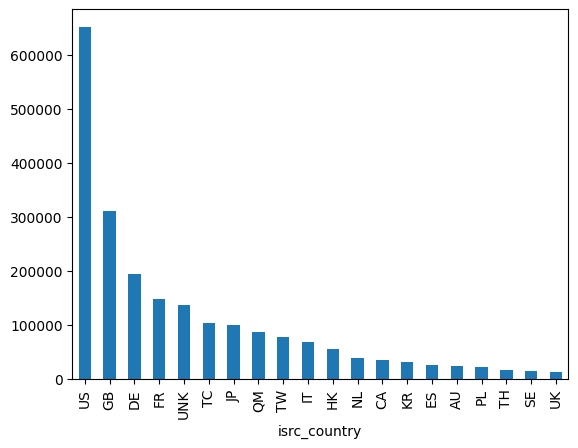

In [ ]:
#以國家分類的數量長條圖
song_merge['isrc_country'].value_counts().head(20).plot(kind='bar')

<Axes: >

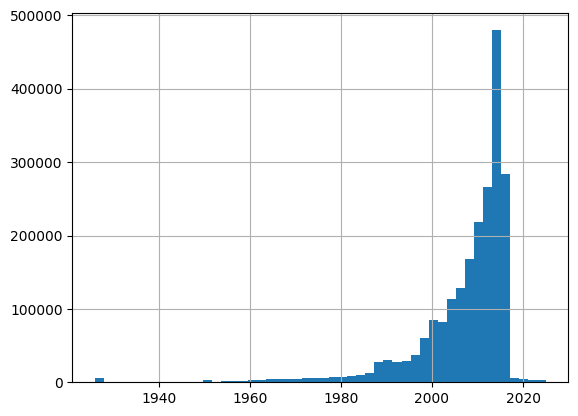

In [ ]:
#歌曲年份圖
song_merge['isrc_year_full'].hist(bins=50)

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

#1.建 genre_list ＋ genre_count
print("1.建 genre_list ＋ genre_count")
def to_genre_list(x):
    if x == "unknown":
        return []          # 沒有 genre，就給空 list
    return x.split('|')     # 多個 genre 用 | 分開

song_merge['genre_list'] = song_merge['genre_ids'].apply(to_genre_list)
song_merge['genre_count'] = song_merge['genre_list'].apply(len)
print(" ")
print("********____genre_____********** ")
print(song_merge[['genre_ids', 'genre_list', 'genre_count']].head(10))
print(" ")


#2.對 genre_list 做 MultiLabelBinarizer 一對多編碼
print("2.對 genre_list 做 MultiLabelBinarizer 一對多編碼")

mlb = MultiLabelBinarizer()
genre_ohe = mlb.fit_transform(song_merge['genre_list'])

genre_cols = [f"genre_{g}" for g in mlb.classes_]
genre_df = pd.DataFrame(genre_ohe, columns=genre_cols, index=song_merge.index)

# 接回原本的 song_merge
song_merge = pd.concat([song_merge, genre_df], axis=1)

print("genre one-hot 欄位數量：", len(genre_cols))
print("前幾個 genre one-hot 欄位：", genre_cols[:10])
print(song_merge[genre_cols[:5] + ['genre_count']].head(10))
print(" ")

print("3. 建立歌手熱門度 artist_popularity")

artist_popularity = song_merge['artist_name'].value_counts()

song_merge['artist_popularity'] = song_merge['artist_name'].map(artist_popularity)

print(song_merge[['artist_name', 'artist_popularity']].head(10))
print("artist_popularity 描述統計：")
print(song_merge['artist_popularity'].describe())
print(" ")

print("4. 建立 artist_popularity_log（避免極端偏態）")

song_merge['artist_popularity_log'] = np.log1p(song_merge['artist_popularity'])

print(song_merge[['artist_name', 'artist_popularity', 'artist_popularity_log']].head(10))
print(" ")

genre_df = genre_df.astype('uint8')

1.建 genre_list ＋ genre_count
 
********____genre_____********** 
         genre_ids            genre_list  genre_count
0              465                 [465]            1
1              444                 [444]            1
2              465                 [465]            1
3              465                 [465]            1
4              726                 [726]            1
5  864|857|850|843  [864, 857, 850, 843]            4
6              458                 [458]            1
7              465                 [465]            1
8              465                 [465]            1
9         352|1995           [352, 1995]            2
 
2.對 genre_list 做 MultiLabelBinarizer 一對多編碼
genre one-hot 欄位數量： 191
前幾個 genre one-hot 欄位： ['genre_1000', 'genre_1007', 'genre_1011', 'genre_1019', 'genre_102', 'genre_1026', 'genre_1033', 'genre_1040', 'genre_1047', 'genre_1054']
   genre_1000  genre_1007  genre_1011  genre_1019  genre_102  genre_count
0           0           0           

In [ ]:
import gc
del genre_ohe, genre_df
gc.collect()

0

In [ ]:
# 確保 artist_name 是字串
song_merge['artist_name'] = song_merge['artist_name'].astype(str)

# 建立 artist_id（依 artist_name 排序，確保穩定）
artist_id_map = (
    song_merge[['artist_name']]
    .drop_duplicates()
    .sort_values('artist_name')
    .reset_index(drop=True)
)
artist_id_map['artist_id'] = artist_id_map.index + 1

# 回填 artist_id 到 song_merge
song_merge = song_merge.merge(
    artist_id_map,
    on='artist_name',
    how='left'
)

import numpy as np

# artist_popularity（每個 artist 出現次數）
artist_popularity = song_merge['artist_name'].value_counts()
song_merge['artist_popularity'] = song_merge['artist_name'].map(artist_popularity)
song_merge['artist_popularity_log'] = np.log1p(song_merge['artist_popularity'])

# ✅ 只做 artist 衍生欄位的 artist_table（不含 composer/lyricist/language）
artist_table = (
    song_merge
    .groupby(['artist_id', 'artist_name'], as_index=False)
    .agg(
        artist_popularity=('artist_popularity', 'max'),
        artist_popularity_log=('artist_popularity_log', 'max'),
    )
)

# 驗證：artist_name 不可重複、每首歌都對得到 artist_id
assert artist_table['artist_name'].is_unique
assert song_merge['artist_id'].isna().sum() == 0

print("artist_table rows =", len(artist_table))
print(artist_table.head())

In [ ]:
print(artist_table.tail(30))

In [ ]:
import numpy as np

# 確保都是字串（避免 NaN / 型別問題）
for col in ['artist_name', 'composer', 'lyricist']:
    song_merge[col] = song_merge[col].astype(str)

# composer 是否「與 artist 不同」
# unknown → 視為一致（False）
song_merge['composer_diff'] = (
    (song_merge['composer'] != 'unknown') &
    (song_merge['composer'] != song_merge['artist_name'])
)

# lyricist 是否「與 artist 不同」
# unknown → 視為一致（False）
song_merge['lyricist_diff'] = (
    (song_merge['lyricist'] != 'unknown') &
    (song_merge['lyricist'] != song_merge['artist_name'])
)

artist_indie_stats = (
    song_merge
    .groupby('artist_id')
    .agg(
        composer_diff_ratio=('composer_diff', 'mean'),
        lyricist_diff_ratio=('lyricist_diff', 'mean'),
    )
    .reset_index()
)

artist_table = artist_table.merge(
    artist_indie_stats,
    on='artist_id',
    how='left'
)

artist_table[['artist_name','composer_diff_ratio', 'lyricist_diff_ratio']].head(20)

artist_table.sort_values('composer_diff_ratio').head(20)
artist_table.sort_values('lyricist_diff_ratio').head(20)

In [ ]:
import os

# Google Drive 中的資料夾路徑
folder_path = "/content/drive/MyDrive/專題資料前處理"

# 建立資料夾（已存在不會報錯）
os.makedirs(folder_path, exist_ok=True)

# 檔案完整路徑
file_path = os.path.join(folder_path, "artist_table.csv")

# 存成 CSV（確保中文不亂碼）
artist_table.to_csv(file_path, index=False, encoding="utf-8-sig")

print(f"已成功儲存到 Google Drive：\n{file_path}")
import pandas as pd

file_path = "/content/drive/MyDrive/專題資料前處理/artist_table.csv"

artist_table_check = pd.read_csv(
    file_path,
    encoding="utf-8-sig"
)

# 印出後 10 筆
artist_table_check.tail(10)

In [ ]:
song_merge['genre_vector'] = song_merge[genre_cols].astype('uint8').values.tolist()
print(song_merge[['genre_ids', 'genre_vector', 'genre_count']].head(10))

In [ ]:
print("5. 建立 metadata_score（欄位是否存在的加總）")

meta_cols_basic = ['has_name', 'has_genre', 'has_composer', 'has_lyricist', 'has_isrc', 'has_song_extra']
song_merge['metadata_score'] = song_merge[meta_cols_basic].sum(axis=1)

print("metadata_score 描述統計：")
print(song_merge['metadata_score'].describe())
print(song_merge[['has_name','has_genre','has_composer','has_lyricist','has_isrc','has_song_extra','metadata_score']].head(10))
print(" ")

print("6. 建立 metadata_score_strict（含 has_valid_isrc）")

meta_cols_strict = ['has_name', 'has_genre', 'has_composer', 'has_lyricist', 'has_valid_isrc', 'has_song_extra']
song_merge['metadata_score_strict'] = song_merge[meta_cols_strict].sum(axis=1)

print("metadata_score_strict 描述統計：")
print(song_merge['metadata_score_strict'].describe())
print(song_merge[meta_cols_strict + ['metadata_score_strict']].head(10))
print(" ")

In [ ]:
print(song_merge.head(2))

In [ ]:
import os

# Google Drive 中的專題資料夾
DATA_DIR = "/content/drive/MyDrive/專題資料前處理"
os.makedirs(DATA_DIR, exist_ok=True)

# 檔案路徑
song_merge_path = os.path.join(DATA_DIR, "song_merge.csv")

# 存成 CSV（確保多語系不亂碼）
song_merge.to_csv(
    song_merge_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"song_merge 已成功儲存：\n{song_merge_path}")
print("rows:", len(song_merge))

### train.csv

要先執行song/train取得轉換後的id

In [ ]:
#1. 填補缺失值
train['source_system_tab'] = train['source_system_tab'].fillna('Unknown')
train['source_screen_name'] = train['source_screen_name'].fillna('Unknown')
train['source_type'] = train['source_type'].fillna('Unknown')

#2. 類別欄位壓縮
source_cols = ['source_system_tab', 'source_screen_name', 'source_type']

for col in source_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    train[col] = train[col].astype('int8') # 強制轉為 int8 省空間

#3.1 ID轉換＿msno
try:
    with open('msno_encoder.pkl', 'rb') as f:
        msno_le = pickle.load(f)

    # 這裡要小心：如果有 train 出現但 members 沒出現的新用戶
    # 為了不報錯，我們先過濾掉那些不在 members 表裡的人(或是用特殊處理)
    # 簡單作法：只保留已知用戶
    known_msno = set(msno_le.classes_)
    train = train[train['msno'].isin(known_msno)]

    train['msno_id'] = msno_le.transform(train['msno'])
    train['msno_id'] = train['msno_id'].astype('int32') # ID 數量多，int8 不夠，用 int32
    train = train.drop(columns=['msno'])

except FileNotFoundError:
    print("找不到 msno_encoder.pkl，請確認是否已執行 members 處理步驟")

#3.2 ID轉換＿song
with open('song_encoder.pkl', 'rb') as f:
    song_encoder = pickle.load(f)

# 建立已知歌曲的名單 (白名單)，避免train 裡面有「不在 song_extra」的歌導致報錯
known_songs = set(song_encoder.classes_)

# 過濾資料：只保留「有在 song_extra 出現過」的歌
before_len = len(train)
train = train[train['song_id'].isin(known_songs)]
after_len = len(train)
print(f"過濾未知歌曲完成：刪除了 {before_len - after_len} 筆資料")

# 開始轉換 (查表)
train['song_id'] = song_encoder.transform(train['song_id'])
train['song_id'] = train['song_id'].astype('int32')

#4.
train['target'] = train['target'].astype('int8')

print(train.head())

過濾未知歌曲完成：刪除了 801 筆資料
   song_id  source_system_tab  source_screen_name  source_type  target  \
1  1425092                  4                   8            5       1   
2   768648                  4                   8            5       1   
3   150553                  4                   8            5       1   
6  1211719                  4                   8            5       1   
8    58203                  4                   8            4       1   

   msno_id  
1     7825  
2     7825  
3     7825  
6     7825  
8    12804  


In [ ]:
# 選出前5000人
# 1. 從train算出每個人聽歌總數
print("計算聽歌活躍度")
member_play_counts = train['msno_id'].value_counts()

# 2. 聽歌次數map回去
complete_members['play_count'] = complete_members['msno_id'].map(member_play_counts)

# 3. 聽歌密度
complete_members['songs_per_day'] = complete_members['play_count'] / complete_members['membership_days'].clip(lower=1)

candidates = complete_members[complete_members['membership_days'] > 30].copy()

# 4. 排序取出前5000人
top_5000_members = candidates.sort_values(by='play_count', ascending=False).head(5000).copy()
del candidates

print("篩選活躍用戶完成")
print(top_5000_members.head(3))
print(f" -最高聽歌次數：{top_5000_members['play_count'].max()}")
print(f" -最低聽歌次數：{top_5000_members['play_count'].min()}")
print(f" -平均聽歌次數：{top_5000_members['play_count'].mean()}")
print(f" -最高聽歌密度：{top_5000_members['songs_per_day'].max()}")
print(f" -最低聽歌密度：{top_5000_members['songs_per_day'].min()}")
print(f" -平均聽歌密度：{top_5000_members['songs_per_day'].mean()}")

計算聽歌活躍度
篩選活躍用戶完成
       city  registered_via  msno_id  bd_group  gender_female  gender_male  \
12033    13               3     5292         3              1            0   
7878     14               3    11372         2              0            1   
8488      5               3     4802         4              1            0   

       registration_year  membership_days  membership_group  city_count  \
12033               2013             1578                 4        2940   
7878                2016              523                 3         615   
8488                2016              214                 2        2323   

       play_count  songs_per_day  
12033      5815.0       3.685044  
7878       5537.0      10.586998  
8488       4216.0      19.700935  
 -最高聽歌次數：5815.0
 -最低聽歌次數：318.0
 -平均聽歌次數：652.4338
 -最高聽歌密度：23.387096774193548
 -最低聽歌密度：0.06564822460776218
 -平均聽歌密度：0.5235816841592288


In [ ]:
import gc # 引入垃圾回收機制

# 1. 取得這 5000 名 VIP 的 ID 清單
# 注意：這裡一定要用 values 轉成 numpy array，速度最快
vip_ids = top_5000_members['msno_id'].values

print(f"原始 train 資料筆數: {len(train)}")

# 2. 【關鍵動作】只保留 ID 在 VIP 清單裡的紀錄
# 使用 .isin() 進行過濾，並加上 .copy() 斷開連結
train_filtered = train[train['msno_id'].isin(vip_ids)].copy()

print(f"篩選後 train 資料筆數: {len(train_filtered)}")
print(f"瘦身比例: 只剩下原資料的 {len(train_filtered) / len(train):.2%}")

# 3. 【釋放記憶體】
# 如果確定原本的 train 不需要了，就把它刪掉
del train
gc.collect()

# 4. 把名字改回來 (可選，方便後續程式碼不用改變數名)
train = train_filtered
print("記憶體清理完成，現在 train 只包含 Top 5000 用戶的數據。")

原始 train 資料筆數: 4277986
篩選後 train 資料筆數: 3262169
瘦身比例: 只剩下原資料的 76.25%
記憶體清理完成，現在 train 只包含 Top 5000 用戶的數據。


In [ ]:
print(train.head(3))

   song_id  source_system_tab  source_screen_name  source_type  target  \
1  1425092                  4                   8            5       1   
2   768648                  4                   8            5       1   
3   150553                  4                   8            5       1   

   msno_id  
1     7825  
2     7825  
3     7825  


In [ ]:
df = train
def calculate_sparsity(df):
    print("正在計算資料集稀疏度...")

    # 1. 計算唯一的使用者數 (Matrix Rows)
    # 如果你的 df 只有 id，請確保是用 msno_id 或 song_id
    if 'msno_id' in df.columns:
        n_users = df['msno_id'].nunique()

    # 2. 計算唯一的歌曲數 (Matrix Columns)
    if 'song_id' in df.columns:
        n_songs = df['song_id'].nunique()

    # 3. 計算實際有的互動數 (Non-zero elements)
    # 也就是資料表原本有的列數
    n_interactions = len(df)

    # 4. 計算矩陣總格子數 (Total elements if fully filled)
    total_cells = n_users * n_songs

    # 5. 計算稀疏度公式
    # 稀疏度 = 1 - (有填值的格子 / 總格子)
    sparsity = 1 - (n_interactions / total_cells)

    # 6. 計算密度 (Density)
    density = n_interactions / total_cells

    print(f"-----------------------------------")
    print(f"📊 矩陣維度: {n_users} (Users) x {n_songs} (Songs)")
    print(f"📦 總格子數: {total_cells:,}")
    print(f"📝 實際紀錄數: {n_interactions:,}")
    print(f"-----------------------------------")
    print(f"🌌 稀疏度 (Sparsity): {sparsity:.4%}")
    print(f"dense 密度 (Density) : {density:.4%}")
    print(f"-----------------------------------")

    return sparsity

# 執行函式
# 如果你是用篩選後的資料，請把 final_train 丟進去
calculate_sparsity(train)

正在計算資料集稀疏度...
-----------------------------------
📊 矩陣維度: 5000 (Users) x 246708 (Songs)
📦 總格子數: 1,233,540,000
📝 實際紀錄數: 3,262,169
-----------------------------------
🌌 稀疏度 (Sparsity): 99.7355%
dense 密度 (Density) : 0.2645%
-----------------------------------


0.9973554412503851

正在計算歌曲播放次數...
-----------------------------------
🎵 歌曲總數: 246708
🔥 前 80% 的播放量，集中在 21137 首歌 (約佔總歌數的 8.57%)
🧊 剩下的 20% 播放量，分散在後面的 225571 首歌 (長尾)
-----------------------------------


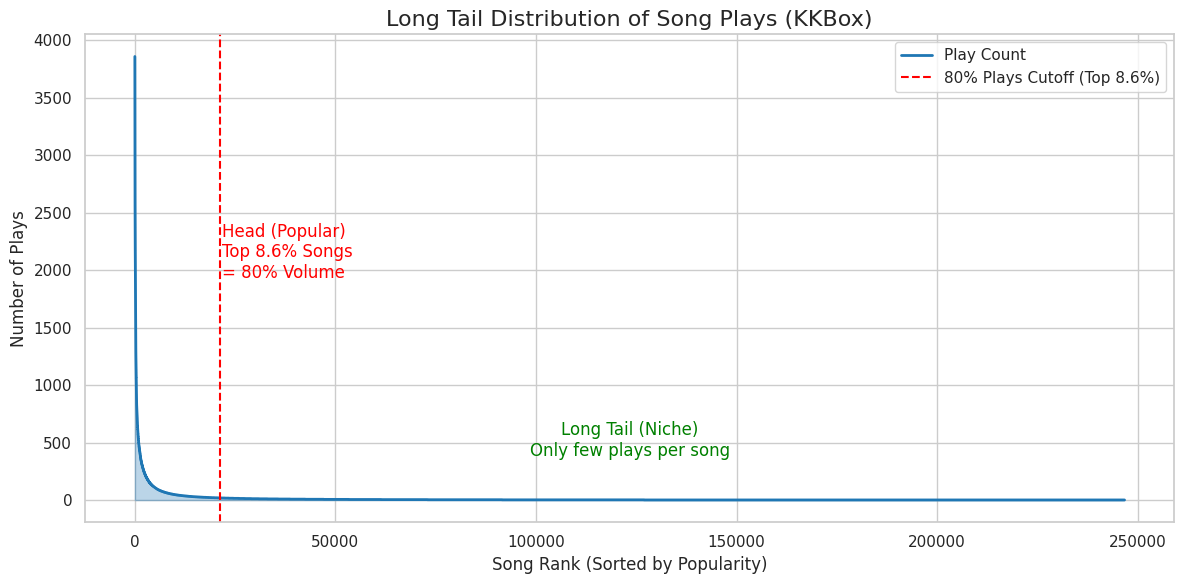

In [ ]:
# 設定繪圖風格
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

# 1. 計算數據
print("正在計算歌曲播放次數...")
# 統計每首歌被聽了幾次，並由大到小排序
song_counts = train_filtered['song_id'].value_counts().values

ranks = np.arange(1, len(song_counts) + 1)

# 計算累積百分比 (用來找 80/20 切點)
cumulative_plays = np.cumsum(song_counts)
total_plays = cumulative_plays[-1]
cumulative_percent = cumulative_plays / total_plays

# 找出 "累積播放量達到 80%" 的那一點 (Pareto Principle)
#這代表：前 X 首歌就佔據了 80% 的流量
pareto_cutoff = np.argmax(cumulative_percent >= 0.8)
pareto_songs_count = pareto_cutoff + 1
pareto_songs_percent = pareto_songs_count / len(song_counts)

print(f"-----------------------------------")
print(f"🎵 歌曲總數: {len(song_counts)}")
print(f"🔥 前 80% 的播放量，集中在 {pareto_songs_count} 首歌 (約佔總歌數的 {pareto_songs_percent:.2%})")
print(f"🧊 剩下的 20% 播放量，分散在後面的 {len(song_counts) - pareto_songs_count} 首歌 (長尾)")
print(f"-----------------------------------")

# 2. 畫圖 (長尾圖)
plt.plot(ranks, song_counts, color='#1f77b4', linewidth=2, label='Play Count')
plt.fill_between(ranks, song_counts, color='#1f77b4', alpha=0.3) # 填色讓尾巴更明顯

# 加上 80/20 切分線
plt.axvline(x=pareto_songs_count, color='red', linestyle='--', label=f'80% Plays Cutoff (Top {pareto_songs_percent:.1%})')

plt.text(pareto_songs_count + 500, song_counts[0]*0.5,
         f'Head (Popular)\nTop {pareto_songs_percent:.1%} Songs\n= 80% Volume',
         color='red', fontsize=12)

plt.text(len(song_counts)*0.5, song_counts[0]*0.1,
         'Long Tail (Niche)\nOnly few plays per song',
         color='green', fontsize=12, ha='center')

# 設定標題與軸
plt.title('Long Tail Distribution of Song Plays (KKBox)', fontsize=16)
plt.xlabel('Song Rank (Sorted by Popularity)', fontsize=12)
plt.ylabel('Number of Plays', fontsize=12)
plt.legend()

# 為了看清楚尾巴，通常這類圖也可以用 Log Scale (對數座標)，你可以把下面這行取消註解試試看
# plt.xscale('log')
# plt.yscale('log')

plt.tight_layout()
plt.show()

#資訊抓取


In [ ]:
pip install pyarrow

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

WD_SPARQL = "https://query.wikidata.org/sparql"

# ✅ 存在 Google Drive（Colab 重啟也不會消）
CACHE_DIR = "/content/drive/MyDrive/kkbox_cache"
CACHE_PATH = f"{CACHE_DIR}/wikidata_isrc_cache.parquet"

os.makedirs(CACHE_DIR, exist_ok=True)

print("Cache dir exists:", os.path.exists(CACHE_DIR))
print("Cache path:", CACHE_PATH)

print("Drive ls:", os.listdir(CACHE_DIR)[:10])


In [ ]:
# 例如你已經有 song_merge
isrc_list = (
    song_merge.loc[song_merge['has_valid_isrc'] == 1, 'isrc']
    .dropna()
    .unique()
    .tolist()
)

# 建議先小規模測試
#isrc_list = isrc_list[:400]
print("unique ISRC:", len(isrc_list))


In [ ]:
import time
import random
import requests
import pandas as pd

import glob
import os
import re


BATCH_SIZE = 200
REQUEST_SLEEP = 1.0
MAX_RETRIES = 4
TIMEOUT = 30

session = requests.Session()
session.headers.update({
    "User-Agent": "kkbox-class-project/0.1 (contact: youremail@example.com)",
    "Accept": "application/sparql-results+json"
})

def safe_sleep(base=REQUEST_SLEEP):
    time.sleep(base + random.random() * 0.2)

def load_cache(path=CACHE_PATH):
    if os.path.exists(path):
        df = pd.read_parquet(path)
        for col in ["isrc", "wd_qid", "label_zh", "desc_zh", "label_en", "desc_en", "typeLabel"]:
            if col not in df.columns:
                df[col] = None
        return df
    return pd.DataFrame(columns=["isrc","wd_qid","label_zh","desc_zh","label_en","desc_en","typeLabel"])

def save_cache(df, path=CACHE_PATH):
    df.to_parquet(path, index=False)

def sparql_request(query: str):
    last_err = None
    for attempt in range(MAX_RETRIES):
        try:
            r = session.get(WD_SPARQL, params={"query": query, "format": "json"}, timeout=TIMEOUT)
            if r.status_code in (429, 500, 502, 503, 504):
                last_err = f"HTTP {r.status_code}"
                time.sleep((2 ** attempt) + random.random())
                continue
            r.raise_for_status()
            return r.json(), None
        except Exception as e:
            last_err = str(e)
            time.sleep((2 ** attempt) + random.random())
    return None, last_err

def build_isrc_query(isrc_batch):
    values = " ".join(f'"{str(x)}"' for x in isrc_batch)
    return f"""
    SELECT ?isrc ?item ?typeLabel ?label_zh ?desc_zh ?label_en ?desc_en WHERE {{
      VALUES ?isrc {{ {values} }}
      ?item wdt:P1243 ?isrc .

      OPTIONAL {{
        ?item rdfs:label ?label_zh .
        FILTER(LANG(?label_zh) = "zh")
      }}
      OPTIONAL {{
        ?item rdfs:label ?label_en .
        FILTER(LANG(?label_en) = "en")
      }}
      OPTIONAL {{
        ?item schema:description ?desc_zh .
        FILTER(LANG(?desc_zh) = "zh")
      }}
      OPTIONAL {{
        ?item schema:description ?desc_en .
        FILTER(LANG(?desc_en) = "en")
      }}

      OPTIONAL {{
        ?item wdt:P31 ?type .
        ?type rdfs:label ?typeLabel .
        FILTER(LANG(?typeLabel) = "en")
      }}
    }}
    """


def fetch_wikidata_by_isrc(isrc_list):
    cache_df = load_cache(CACHE_PATH)
    done = set(cache_df["isrc"].astype(str).tolist())

    todo = [str(x) for x in isrc_list if str(x) not in done]
    print(f"Cache already has {len(done)} rows. Todo: {len(todo)}")

    total = len(todo)

    for start in range(0, total, BATCH_SIZE):
        batch = todo[start:start+BATCH_SIZE]

        q = build_isrc_query(batch)
        data, err = sparql_request(q)
        safe_sleep()

        batch_rows = []  # ✅ 每個 batch 自己的 rows

        if err:
            for isrc in batch:
                batch_rows.append({
                    "isrc": isrc, "wd_qid": None,
                    "label_zh": None, "desc_zh": None,
                    "label_en": None, "desc_en": None,
                    "typeLabel": None
                })
            print(f"[Batch {start//BATCH_SIZE+1}] error: {err}")

        else:
            bindings = data.get("results", {}).get("bindings", [])
            seen = {}

            for b in bindings:
                isrc = b.get("isrc", {}).get("value")
                item = b.get("item", {}).get("value")
                qid = item.rsplit("/", 1)[-1] if item else None
                if not isrc:
                    continue

                candidate = {
                    "isrc": isrc,
                    "wd_qid": qid,
                    "label_zh": b.get("label_zh", {}).get("value") or None,
                    "desc_zh": b.get("desc_zh", {}).get("value") or None,
                    "label_en": b.get("label_en", {}).get("value") or None,
                    "desc_en": b.get("desc_en", {}).get("value") or None,
                    "typeLabel": b.get("typeLabel", {}).get("value") or None,
                }

                # ✅ 優先保留有 desc 的版本
                if (isrc not in seen) or (seen[isrc].get("desc_en") is None and candidate.get("desc_en") is not None):
                    seen[isrc] = candidate

            for isrc in batch:
                if isrc in seen:
                    batch_rows.append(seen[isrc])
                else:
                    batch_rows.append({
                        "isrc": isrc,
                        "wd_qid": None,
                        "label_zh": None, "desc_zh": None,
                        "label_en": None, "desc_en": None,
                        "typeLabel": None
                    })

        # ✅ 直接把這個 batch 存進 cache
        cache_df = pd.concat([cache_df, pd.DataFrame(batch_rows)], ignore_index=True)
        save_cache(cache_df, CACHE_PATH)

        got = cache_df["wd_qid"].notna().sum()
        processed = min(start + BATCH_SIZE, total)
        print(f"[Saved] total={len(cache_df)} matched={got} (processed {processed}/{total})")

    print("Done. Cache saved to:", CACHE_PATH)
    return cache_df

def fetch_wikidata_batch_and_save(batch, out_path):
    q = build_isrc_query(batch)
    data, err = sparql_request(q)
    safe_sleep()

    rows = []
    if err:
        for isrc in batch:
            rows.append({"isrc": str(isrc), "wd_qid": None,
                         "label_zh": None, "desc_zh": None,
                         "label_en": None, "desc_en": None, "typeLabel": None})
        pd.DataFrame(rows).to_parquet(out_path, index=False)
        return

    bindings = data.get("results", {}).get("bindings", [])
    seen = {}
    for b in bindings:
        isrc = b.get("isrc", {}).get("value")
        item = b.get("item", {}).get("value")
        qid = item.rsplit("/", 1)[-1] if item else None
        if not isrc:
            continue
        candidate = {
            "isrc": isrc, "wd_qid": qid,
            "label_zh": b.get("label_zh", {}).get("value") or None,
            "desc_zh": b.get("desc_zh", {}).get("value") or None,
            "label_en": b.get("label_en", {}).get("value") or None,
            "desc_en": b.get("desc_en", {}).get("value") or None,
            "typeLabel": b.get("typeLabel", {}).get("value") or None,
        }
        if (isrc not in seen) or (seen[isrc].get("desc_en") is None and candidate.get("desc_en") is not None):
            seen[isrc] = candidate

    for isrc in map(str, batch):
        rows.append(seen.get(isrc, {"isrc": isrc, "wd_qid": None,
                                    "label_zh": None, "desc_zh": None,
                                    "label_en": None, "desc_en": None, "typeLabel": None}))

    pd.DataFrame(rows).to_parquet(out_path, index=False)


#wd_cache = fetch_wikidata_by_isrc(isrc_list)
#wd_cache = fetch_wikidata_by_isrc(isrc_list[:400])
#wd_cache.head(10)
#print("matched rate:", wd_cache["wd_qid"].notna().mean())

def get_resume_start(part_dir, chunk=400):
    files = sorted(glob.glob(f"{part_dir}/wd_*.parquet"))
    if not files:
        return None  # 沒有 parts 檔
    # 從檔名抓 end index
    max_end = -1
    for f in files:
        m = re.search(r"wd_(\d+)_(\d+)\.parquet$", os.path.basename(f))
        if m:
            end = int(m.group(2))
            max_end = max(max_end, end)
    return max_end + 1  # 下一個 start

start_from_parts = get_resume_start(PART_DIR, CHUNK)
start_from_parts

done_cache = 0
if os.path.exists(CACHE_PATH):
    done_cache = len(pd.read_parquet(CACHE_PATH, columns=["isrc"]))  # 只讀一欄，省 RAM

start_from_parts = start_from_parts or 0
START = max(done_cache, start_from_parts)

print("done_cache:", done_cache)
print("start_from_parts:", start_from_parts)
print("RESUME START:", START)



CHUNK = 400
MAX_RUN = None   # None = 跑到尾；例如 4000 = 只跑 4000 筆

START = start_from_parts  # 726000

if MAX_RUN is None:
    end_limit = len(isrc_list)
else:
    end_limit = min(len(isrc_list), START + MAX_RUN)

print("START:", START)
print("END_LIMIT:", end_limit)

for start in range(START, end_limit, CHUNK):
    batch = isrc_list[start:start+CHUNK]
    out_path = f"{PART_DIR}/wd_{start}_{start+len(batch)-1}.parquet"
    print(f"\n=== Run chunk {start}~{start+len(batch)-1} ===")
    fetch_wikidata_batch_and_save(batch, out_path)





#for start in range(722000 , len(isrc_list), CHUNK):
#    print(f"\n=== Run chunk {start}~{start+len(batch)-1} ===")
#    fetch_wikidata_by_isrc(batch)

    # 看一下目前累積進度
#    df = pd.read_parquet(CACHE_PATH)
#    print("cache rows:", len(df), "matched:", df["wd_qid"].notna().sum())


#wd_cache = pd.read_parquet(CACHE_PATH)
#print("cache rows:", len(wd_cache))
#print("unique isrc:", wd_cache["isrc"].nunique())


In [ ]:
import pandas as pd

wd_cache = pd.read_parquet(
    "/content/drive/MyDrive/kkbox_cache/wikidata_isrc_cache.parquet"
)

matched = wd_cache[wd_cache["wd_qid"].notna()].copy()
print("matched rows =", len(matched))
print(matched[["isrc","wd_qid","label_zh","desc_zh","label_en","desc_en","typeLabel"]])


##wikidata

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

WD_SPARQL = "https://query.wikidata.org/sparql"

# ✅ 存在 Google Drive（Colab 重啟也不會消）
CACHE_DIR = "/content/drive/MyDrive/kkbox_cache"
CACHE_PATH = f"{CACHE_DIR}/wikidata_isrc_cache.parquet"

os.makedirs(CACHE_DIR, exist_ok=True)

print("Cache dir exists:", os.path.exists(CACHE_DIR))
print("Cache path:", CACHE_PATH)

print("Drive ls:", os.listdir(CACHE_DIR)[:10])


In [ ]:
import pandas as pd
import os

CACHE_PATH = "/content/drive/MyDrive/kkbox_cache/wikidata_isrc_cache.parquet"
OUT_DIR = "/content/drive/MyDrive/kkbox_cache"
OUT_CSV = os.path.join(OUT_DIR, "wikidata_isrc_matched.csv")

os.makedirs(OUT_DIR, exist_ok=True)

# 1) 讀取 Wikidata cache
wd_cache = pd.read_parquet(CACHE_PATH)

# 2) 只留你要的欄位（沒有的欄位會自動略過）
cols = ["isrc", "wd_qid", "label_zh", "desc_zh", "label_en", "desc_en", "typeLabel"]
cols = [c for c in cols if c in wd_cache.columns]
wd = wd_cache[cols].copy()

# 3) 篩出 matched（wd_qid 不為空）
wd_matched = wd[wd["wd_qid"].notna()].copy()

print("matched rows:", len(wd_matched))
print("unique isrc before dedup:", wd_matched["isrc"].nunique())

# 4)（建議）同一個 ISRC 可能在 cache 出現多筆 → 先去重，避免之後 merge 乘開
#    規則：優先保留 desc 有內容的那筆
has_desc = wd_matched.get("desc_en", pd.Series([pd.NA]*len(wd_matched))).notna() | \
           wd_matched.get("desc_zh", pd.Series([pd.NA]*len(wd_matched))).notna()
wd_matched["_has_desc"] = has_desc

wd_matched = (
    wd_matched.sort_values(by=["_has_desc"], ascending=False)
              .drop_duplicates(subset=["isrc"], keep="first")
              .drop(columns=["_has_desc"])
)

print("unique isrc after dedup:", wd_matched["isrc"].nunique())

# 5) 存成 CSV（utf-8-sig：Excel 開不會亂碼）
wd_matched.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")
print("Saved:", OUT_CSV)


In [ ]:
import pandas as pd
import os

CACHE_PATH = "/content/drive/MyDrive/kkbox_cache/wikidata_isrc_cache.parquet"
OUT_DIR = "/content/drive/MyDrive/kkbox_cache"
os.makedirs(OUT_DIR, exist_ok=True)

wd_cache = pd.read_parquet(CACHE_PATH)

# ✅ 只留英文相關欄位 + type
cols = ["isrc", "wd_qid", "label_en", "desc_en", "typeLabel"]
cols = [c for c in cols if c in wd_cache.columns]
wd = wd_cache[cols].copy()

# ✅ 只留 matched（有 wd_qid）
wd_matched = wd[wd["wd_qid"].notna()].copy()

# ========= (A) RAW：保留所有版本（檔名改掉，避免覆蓋） =========
raw_path = os.path.join(OUT_DIR, "wikidata_isrc_matched_en_raw.csv")
wd_matched.to_csv(raw_path, index=False, encoding="utf-8-sig")
print("Saved RAW (EN):", raw_path, "rows:", len(wd_matched), "unique isrc:", wd_matched["isrc"].nunique())

# ========= (B) 聚合：每個 ISRC 一筆（用來 merge） =========
def uniq_join(series):
    vals = [str(x).strip() for x in series.dropna().tolist() if str(x).strip() != ""]
    seen, out = set(), []
    for v in vals:
        if v not in seen:
            seen.add(v)
            out.append(v)
    return " || ".join(out) if out else pd.NA

# 每個欄位的聚合規則：去重後串起來
agg_dict = {c: uniq_join for c in cols if c != "isrc"}

wd_by_isrc = (
    wd_matched
    .groupby("isrc", as_index=False)
    .agg(agg_dict)
)

by_isrc_path = os.path.join(OUT_DIR, "wikidata_isrc_matched_en_by_isrc.csv")
wd_by_isrc.to_csv(by_isrc_path, index=False, encoding="utf-8-sig")
print("Saved BY_ISRC (EN):", by_isrc_path, "rows:", len(wd_by_isrc), "unique isrc:", wd_by_isrc["isrc"].nunique())

# （可選）印出前 20 列確認
print("\n=== Preview 20 rows (RAW EN) ===")
print(wd_matched.head(20))

print("\n=== Preview 20 rows (BY_ISRC EN) ===")
print(wd_by_isrc.head(20))


In [ ]:
import pandas as pd
import os
import re

CACHE_PATH = "/content/drive/MyDrive/kkbox_cache/wikidata_isrc_cache.parquet"
OUT_DIR = "/content/drive/MyDrive/kkbox_cache"
os.makedirs(OUT_DIR, exist_ok=True)

wd_cache = pd.read_parquet(CACHE_PATH)

# ✅ 只留英文相關欄位 + type
cols = ["isrc", "wd_qid", "label_en", "desc_en", "typeLabel"]
cols = [c for c in cols if c in wd_cache.columns]
wd = wd_cache[cols].copy()

# ✅ 只留 matched（有 wd_qid）
wd_matched = wd[wd["wd_qid"].notna()].copy()

# ========= (A) RAW：保留所有版本 =========
raw_path = os.path.join(OUT_DIR, "wikidata_isrc_matched_en_raw.csv")
wd_matched.to_csv(raw_path, index=False, encoding="utf-8-sig")
print("Saved RAW (EN):", raw_path, "rows:", len(wd_matched), "unique isrc:", wd_matched["isrc"].nunique())

# ========= (B) 聚合：每個 ISRC 一筆（用來 merge） =========
def uniq_join(series):
    vals = [str(x).strip() for x in series.dropna().tolist() if str(x).strip() != ""]
    seen, out = set(), []
    for v in vals:
        if v not in seen:
            seen.add(v)
            out.append(v)
    return " || ".join(out) if out else pd.NA

agg_dict = {c: uniq_join for c in cols if c != "isrc"}

wd_by_isrc = (
    wd_matched
    .groupby("isrc", as_index=False)
    .agg(agg_dict)
)

# ========= ✅ 新增欄位：has_feat / is_single / has_vocal =========
def _safe_lower(x):
    return ("" if pd.isna(x) else str(x)).lower()

# has_feat：desc_en 裡只要出現 feat./featuring/ ft 就算 True
wd_by_isrc["has_feat"] = wd_by_isrc["desc_en"].apply(
    lambda x: bool(re.search(r"\b(feat\.|featuring|ft\.?)\b", _safe_lower(x)))
)

# is_single：typeLabel 只要包含 single 就算 True（聚合後可能是 "single || song"）
wd_by_isrc["is_single"] = wd_by_isrc["typeLabel"].apply(
    lambda x: "single" in _safe_lower(x)
)

# has_vocal：typeLabel 只要包含 "with vocals" 就算 True（對應 music track with vocals）
wd_by_isrc["has_vocal"] = wd_by_isrc["typeLabel"].apply(
    lambda x: "with vocals" in _safe_lower(x)
)

# ========= 存檔 =========
by_isrc_path = os.path.join(OUT_DIR, "wikidata_isrc_matched_en_by_isrc.csv")
wd_by_isrc.to_csv(by_isrc_path, index=False, encoding="utf-8-sig")
print("Saved BY_ISRC (EN):", by_isrc_path, "rows:", len(wd_by_isrc), "unique isrc:", wd_by_isrc["isrc"].nunique())

# （可選）印出前 20 列確認
print("\n=== Preview 20 rows (RAW EN) ===")
print(wd_matched.head(20))

print("\n=== Preview 20 rows (BY_ISRC EN) ===")
print(wd_by_isrc[["isrc","wd_qid","label_en","desc_en","typeLabel","has_feat","is_single","has_vocal"]].head(20))


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/kkbox_cache"))


In [ ]:
import pandas as pd
from IPython.display import display

# 讀 by_isrc（每 isrc 一筆）
wd_by_isrc = pd.read_csv("/content/drive/MyDrive/kkbox_cache/wikidata_isrc_matched_en_by_isrc.csv")

# key 正規化
song_merge["isrc"] = song_merge["isrc"].astype("string").str.strip().str.upper()
wd_by_isrc["isrc"] = wd_by_isrc["isrc"].astype("string").str.strip().str.upper()

# 你想從 song_merge 帶過去的欄位（可自行加減）
song_cols = ["song_id_new", "name", "artist_name", "genre_ids", "language", "song_length", "composer", "lyricist", "isrc"]
song_cols = [c for c in song_cols if c in song_merge.columns]

# inner：只保留「有 wikidata match」的歌曲
matched_with_song = wd_by_isrc.merge(song_merge[song_cols], how="inner", on="isrc")

print("wd_by_isrc unique isrc:", wd_by_isrc["isrc"].nunique())
print("matched_with_song rows:", len(matched_with_song))
print("unique isrc in result:", matched_with_song["isrc"].nunique())

display(matched_with_song.head(100))


In [ ]:
import pandas as pd
from IPython.display import display

# 讀 Wikidata（每 isrc 一筆）
wd_by_isrc = pd.read_csv(
    "/content/drive/MyDrive/kkbox_cache/wikidata_isrc_matched_en_by_isrc.csv"
)

# key 正規化
song_merge["isrc"] = song_merge["isrc"].astype("string").str.strip().str.upper()
wd_by_isrc["isrc"] = wd_by_isrc["isrc"].astype("string").str.strip().str.upper()

# left merge：保留所有歌曲，能對到的才補 Wikidata
song_merge_with_wiki = song_merge.merge(
    wd_by_isrc,
    how="left",
    on="isrc"
)

print("song_merge rows:", len(song_merge))
print("after merge rows:", len(song_merge_with_wiki))
print("songs with wikidata:", song_merge_with_wiki["wd_qid"].notna().sum())

display(song_merge_with_wiki.head(100))


# Baseline

In [ ]:
# 最省RAM，把train.csv轉成(msno_id, song_id, target)
# 只針對 complete_members 使用者 + song_extra 收錄歌曲 的子資料集做模型比較
# 最主要原因：user encoder 只涵蓋 complete_members
# 第二個原因：song encoder 只涵蓋 song_extra_info 出現的 song_id

import pandas as pd
import numpy as np
import pickle
import gc

def load_and_encode_train_for_knn(
    train_csv_path: str,
    msno_encoder_path: str,
    song_encoder_path: str,
    usecols=("msno", "song_id", "target"),
    chunksize=2_000_000
):
    """
    目的（省 RAM + 與你們宇宙一致）：
    - 只讀 train.csv 的必要欄位
    - 用你們已存的 msno_encoder.pkl / song_encoder.pkl 做 transform
    - 對未知 user/song 做白名單過濾（避免 transform 報錯）
    - 回傳最終只包含 [msno_id, song_id, target] 的 DataFrame

    省 RAM 關鍵：
    - 用 chunksize 分批讀，不一次把整個 train.csv 放進 RAM
    """
    # 讀入 encoders（你們既有宇宙）
    with open(msno_encoder_path, "rb") as f:
        msno_le = pickle.load(f)
    with open(song_encoder_path, "rb") as f:
        song_le = pickle.load(f)

    known_msno = set(msno_le.classes_)
    known_song = set(song_le.classes_)

    out_parts = []
    total_in = 0
    total_keep = 0

    for chunk in pd.read_csv(train_csv_path, usecols=list(usecols), chunksize=chunksize):
        total_in += len(chunk)

        # 1) 先白名單過濾（避免 encoder transform 報錯）
        chunk = chunk[chunk["msno"].isin(known_msno)]
        chunk = chunk[chunk["song_id"].isin(known_song)]

        if len(chunk) == 0:
            continue

        # 2) transform -> 整數 id
        chunk["msno_id"] = msno_le.transform(chunk["msno"]).astype(np.int32)
        chunk["song_id"] = song_le.transform(chunk["song_id"]).astype(np.int32)

        # 3) 保留必要欄位
        chunk["target"] = chunk["target"].astype(np.int8)
        chunk = chunk[["msno_id", "song_id", "target"]]

        out_parts.append(chunk)
        total_keep += len(chunk)

        # 釋放記憶體
        del chunk
        gc.collect()

    if not out_parts:
        raise ValueError("沒有任何資料通過白名單過濾，請檢查 encoder 路徑或 train.csv 欄位。")

    train_encoded = pd.concat(out_parts, ignore_index=True)
    print(f"讀入原始筆數（分批累計）：{total_in:,}")
    print(f"白名單過濾後保留筆數：{total_keep:,}")
    print(f"最終 train_encoded shape：{train_encoded.shape}")

    return train_encoded


train_csv_path = "/content/data/kkbox_datasets/train.csv"
msno_encoder_path = "/content/msno_encoder.pkl"
song_encoder_path = "/content/song_encoder.pkl"
train_encoded = load_and_encode_train_for_knn(train_csv_path, msno_encoder_path, song_encoder_path)

讀入原始筆數（分批累計）：7,377,418
白名單過濾後保留筆數：4,277,986
最終 train_encoded shape：(4277986, 3)


In [ ]:
#最省RAM，跑KNN的notebook只要讀complete_members_small.csv
#Top5000需要membership_days

complete_members[['msno_id','membership_days']].to_csv(
    "/content/complete_members_small.csv",
    index=False,
    encoding="utf-8-sig"
)

In [ ]:
# ============================================================
# Baseline Item-based KNN（Implicit, target==1）完整可跑版本
# - 研究型評估：Leave-One-Out (per user)
# - 指標：Recall@K、Precision@K、NDCG@K
# - 輸出：metrics 表格 + demo 推薦清單 CSV
#
# Top5000 與之前資料清洗流程的 Top5000 完全一致
# - 活躍度 play_count：用 train（白名單後）全部互動筆數（不分 target）
# - 條件：membership_days > 30（來自 complete_members）
# - 取 play_count 前 5000 名
# ============================================================

import gc # 手動釋放記憶體（Google Colab RAM 非常重要）
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix # user–item matrix 是「極度稀疏」，一定要用 sparse matrix
from sklearn.neighbors import NearestNeighbors # sklearn 的 KNN 實作（支援 cosine + sparse）

# -----------------------------
# (0) 全域參數設定（可調）
# -----------------------------
RANDOM_SEED = 42 # 控制 Leave-One-Out 隨機抽 test item
          # 讓結果可重現

# Item-based KNN 的超參數
ITEM_K = 5     # 每首歌保留幾個最相似鄰居（越大越慢、越吃記憶體）
RECO_N = 20     # 每位使用者輸出 Top-N 推薦
EVAL_KS = (10, 20) # 評估指標要看 @10, @20推薦品質

# Leave-One-Out 需要每位使用者至少要有 2 首正例（1 首當 test，至少 1 首留在 train）
MIN_POS_PER_USER = 2

# 使用Top5000（這裡固定True），所有模型都只在 Top5000 用戶上跑
USE_TOP_USERS = True
TOP_N_USERS = 5000

# 省資源用：你可以丟掉太冷門的歌，避免item數爆炸（目前沒開為False）
# 目前完整保留長尾
USE_MIN_ITEM_FREQ = False
MIN_ITEM_FREQ = 3


# -----------------------------
# (1) 依前處理定義，選出 Top5000 用戶（100%一致）
# -----------------------------
def select_top_users_same_as_preprocess(
    train_encoded: pd.DataFrame,
    complete_members_small: pd.DataFrame,
    top_n_users: int = 5000,
    min_membership_days: int = 30
) -> np.ndarray:
    """
    目的：
    - 完全複製先前資料清洗流程的 Top5000 取法
    - 你們先前定義：
      1) play_count = train['msno_id'].value_counts()  （不分target）
      2) candidates = complete_members[membership_days > 30]
      3) top_5000_members = candidates.sort_values(by='play_count', ascending=False).head(5000)

    輸入：
    - train_encoded：至少含 msno_id/song_id/target（目前已轉好ID且白名單過濾過）
    - complete_members_small：只需要兩欄 msno_id, membership_days（省RAM）

    輸出：
    - top_users：np.ndarray，長度=top_n_users 的 msno_id 清單
    """
    # 基本欄位檢查
    if "msno_id" not in train_encoded.columns:
        raise ValueError("train_encoded 必須包含 msno_id")
    if not {"msno_id", "membership_days"}.issubset(set(complete_members_small.columns)):
        raise ValueError("complete_members_small 必須包含 msno_id 與 membership_days")

    # (1) 用「全部互動」算 play_count（注意：不分 target，這樣才會與你們之前一致）
    play_count = train_encoded["msno_id"].value_counts()

    # (2) 只保留 membership_days > 30 的 candidates（你們之前就是這樣做）
    candidates = complete_members_small[complete_members_small["membership_days"] > min_membership_days].copy()

    # (3) 把 play_count map 回 candidates
    # 沒出現在 train 的用戶 play_count 會是 NaN → 補 0
    candidates["play_count"] = candidates["msno_id"].map(play_count).fillna(0).astype(np.int32)

    # (4) 取 play_count 最大的 Top-N
    top_users = (
        candidates.sort_values("play_count", ascending=False)
        .head(top_n_users)["msno_id"]
        .to_numpy(dtype=np.int32)
    )

    return top_users

# 把原本幾百萬筆train縮成只屬於Top5000用戶的子集
def filter_train_to_top_users(train_encoded: pd.DataFrame, top_users: np.ndarray) -> pd.DataFrame:
    """
    目的：
    - 用 Top5000 用戶名單去過濾 train_encoded
    - 後續所有模型（KNN/MF/LightFM）都沿用這份子集，確保一致性
    """
    filtered = train_encoded[train_encoded["msno_id"].isin(top_users)].copy()
    filtered.reset_index(drop=True, inplace=True)
    return filtered


# -----------------------------
# (2) 資料準備：只留 KNN 需要的三欄，並轉成 implicit positives
# -----------------------------
def prepare_train_for_knn(train_subset: pd.DataFrame) -> pd.DataFrame:
    """
    目的：
    - 確保 train_subset 至少有 msno_id、song_id、target 三欄
    - 只保留這三欄，節省 RAM
    - 只留 target==1 的正回饋（re-listen）當作 implicit positives(隱性正回饋)
    - 去掉 user-song 重複（避免重複互動影響）
    """
    required = {"msno_id", "song_id", "target"}
    missing = required - set(train_subset.columns)
    if missing:
        raise ValueError(f"train_subset 缺少必要欄位：{missing}")

    df = train_subset.loc[:, ["msno_id", "song_id", "target"]].copy()

    # 只保留正例互動（target==1）
    df = df[df["target"] == 1].drop(columns=["target"])

    # 去掉重複互動：一個 user 對同一首歌只算一次
    # 防止同一 user 重聽很多次同一首歌，有重複記錄到，導致這首歌權重被放大(理論上不會出現)
    df = df.drop_duplicates(["msno_id", "song_id"]).reset_index(drop=True)

    # 型態壓縮
    df["msno_id"] = df["msno_id"].astype(np.int32)
    df["song_id"] = df["song_id"].astype(np.int32)

    return df


In [ ]:
# -----------------------------
# (3) 可選：丟掉太冷門歌曲（省 item 數），目前沒開為False
# -----------------------------
def filter_items_by_min_freq(pos_df: pd.DataFrame, min_freq: int = 3) -> pd.DataFrame:
    """
    目的：
    - 過濾互動次數太少的歌曲（極冷門 item）
    - 好處：
        1) item 數量顯著下降
        2) item-based KNN 計算更快
        3) 記憶體使用量更低
    - 代價：
        - 會犧牲一部分「長尾歌曲」
        - 若研究重點是 long-tail recommendation，則不建議開啟
    """
    # 計算每首歌在正例資料（target==1）中出現的次數
    # → 這裡的次數代表「有多少使用者真的重聽過這首歌」
    item_counts = pos_df["song_id"].value_counts()

    # 只保留互動次數 >= min_freq 的歌曲
    # → 極少數人聽過的歌，item-based KNN 幾乎無法學到穩定相似度
    keep_items = item_counts[item_counts >= min_freq].index

    # 過濾資料，只留下保留清單中的歌曲
    filtered = pos_df[pos_df["song_id"].isin(keep_items)].copy()

    # 重設 index，避免後續 groupby / sparse matrix 建立出現潛在問題
    filtered.reset_index(drop=True, inplace=True)
    return filtered


# -----------------------------
# (4) Leave-One-Out split（每人留 1 首正例當測試）
# -----------------------------
def leave_one_out_split(pos_df: pd.DataFrame,
                        min_pos_per_user: int = 2,
                        seed: int = 42):
    """
    目的：
    - 進行 Leave-One-Out（LOO）評估切分
    - 對每一位使用者：
        1) 從其正例歌曲中隨機抽 1 首當作 test
        2) 其餘正例歌曲作為 train
    - 只保留正例數 >= min_pos_per_user 的使用者
      （否則抽掉 1 首後，train 會是空的，無法推薦）
    """
    # 建立可重現的亂數產生器（確保實驗可重現）
    rng = np.random.default_rng(seed)

    # 計算每位使用者的正例歌曲數
    counts = pos_df["msno_id"].value_counts()

    # 只保留正例數量 >= min_pos_per_user 的使用者
    eligible_users = counts[counts >= min_pos_per_user].index

    # 過濾資料，只留下符合條件的使用者
    df = pos_df[pos_df["msno_id"].isin(eligible_users)].copy()

    train_rows = []  # 儲存 (user, song) 的訓練資料
    test_rows = []   # 儲存 (user, test_song) 的測試資料

    # 對每一位使用者 individually 做 LOO
    for u, g in df.groupby("msno_id", sort=False):
        # 取出該使用者所有正例歌曲
        items = g["song_id"].to_numpy()

        # 隨機選一首歌作為 test
        test_idx = rng.integers(0, len(items))
        test_item = items[test_idx]

        # 其餘歌曲作為 train
        train_items = np.delete(items, test_idx)

        # 存 test
        test_rows.append((u, test_item))

        # 存 train
        for it in train_items:
            train_rows.append((u, it))

    # 組成 DataFrame
    train_split = pd.DataFrame(train_rows, columns=["msno_id", "song_id"])
    test_split = pd.DataFrame(test_rows, columns=["msno_id", "test_song_id"])

    return train_split, test_split


# -----------------------------
# (5) 建立連續索引（因為 sparse matrix 需要 0..n-1）
# -----------------------------
def build_index_maps(train_split: pd.DataFrame):
    """
    目的：
    - 原始 msno_id / song_id 雖然是整數，但不保證連續
      （例如：0, 3, 7, 1024...）
    - sparse matrix 必須使用 0 ~ N-1 的連續索引
    - 因此需要建立：
        原始 ID → matrix index
        matrix index → 原始 ID
    """
    # 取出訓練集中出現過的所有使用者與歌曲
    unique_users = train_split["msno_id"].unique()
    unique_items = train_split["song_id"].unique()

    # user 原始 ID → matrix row index
    user2idx = {u: i for i, u in enumerate(unique_users)}

    # matrix row index → user 原始 ID（方便之後輸出推薦結果）
    idx2user = np.array(unique_users, dtype=np.int32)

    # item 原始 ID → matrix column index
    item2idx = {it: j for j, it in enumerate(unique_items)}

    # matrix column index → item 原始 ID
    idx2item = np.array(unique_items, dtype=np.int32)

    return user2idx, idx2user, item2idx, idx2item


def build_user_item_matrix(train_split: pd.DataFrame, user2idx, item2idx):
    """
    目的：
    - 建立 user-item implicit interaction matrix（binary）
    - X_ui[u, i] = 1 代表：
        使用者 u 在訓練資料中「確實喜歡（重聽）」過歌曲 i
    - 不使用播放次數或權重，純 binary（baseline 設計）
    """
    # 將原始 user_id / song_id 映射為連續索引
    rows = train_split["msno_id"].map(user2idx).to_numpy()
    cols = train_split["song_id"].map(item2idx).to_numpy()

    # 每一筆互動都是 1（implicit feedback）
    data = np.ones(len(train_split), dtype=np.float32)

    n_users = len(user2idx)
    n_items = len(item2idx)

    # 建立 CSR sparse matrix
    # shape = (使用者數, 歌曲數)
    X_ui = csr_matrix((data, (rows, cols)), shape=(n_users, n_items))

    return X_ui


# -----------------------------
# (6) 訓練 item-based KNN：對 item 向量做 cosine 近鄰
# -----------------------------
def fit_item_knn(X_ui: csr_matrix, item_k: int = 200):
    """
    目的：
    - 建立 item-based KNN 模型
    - 每一首歌視為一個向量：向量維度 = 有哪些使用者喜歡過它
    - 使用 cosine similarity 衡量歌曲之間的相似度
    """
    # 將 user-item matrix 轉置為 item-user matrix
    # 原本：users x items
    # 轉置後：items x users
    X_iu = X_ui.T.tocsr()

    # 建立 KNN 模型
    nn = NearestNeighbors(
        n_neighbors=item_k + 1,  # +1 是因為第一個鄰居通常是自己
        metric="cosine",      # cosine distance = 1 - cosine similarity
        algorithm="brute",     # 對 sparse + cosine 最穩定
        n_jobs=-1          # 使用所有 CPU 核心
    )
    nn.fit(X_iu)

    # 對每一首歌，找出最相似的 K+1 首歌
    distances, indices = nn.kneighbors(X_iu, return_distance=True)

    # 將距離轉成相似度
    sims = 1.0 - distances

    # 移除「自己」這個鄰居（第 0 個）
    neigh_items = indices[:, 1:]
    neigh_sims = sims[:, 1:]

    return neigh_items, neigh_sims


# -----------------------------
# (7) 推薦：用 seed items 的鄰居相似度做加總
# -----------------------------
def recommend_for_user(user_idx: int,
                       X_ui: csr_matrix,
                       neigh_items: np.ndarray,
                       neigh_sims: np.ndarray,
                       top_n: int = 20,
                       aggregation: str = "baseline",
                       sim_threshold: float = 0.0):
    s, e = X_ui.indptr[user_idx], X_ui.indptr[user_idx + 1]
    user_items = X_ui.indices[s:e]

    if user_items.size == 0:
        return np.array([], dtype=np.int32), np.array([], dtype=np.float32)

    seen = set(user_items.tolist())
    scores = {}

    num_seed = int(user_items.size)

    for it in user_items:
        for nb, sim in zip(neigh_items[it], neigh_sims[it]):
            if nb in seen:
                continue
            if sim <= sim_threshold:   # threshold=0.0 等於關閉（只排除 <=0）
                continue

            if aggregation == "normalize_seed":
                add = float(sim) / num_seed
            else:  # baseline
                add = float(sim)

            scores[nb] = scores.get(nb, 0.0) + add

    if not scores:
        return np.array([], dtype=np.int32), np.array([], dtype=np.float32)

    cand_items = np.fromiter(scores.keys(), dtype=np.int32)
    cand_scores = np.fromiter(scores.values(), dtype=np.float32)

    if cand_items.size > top_n:
        top_idx = np.argpartition(-cand_scores, top_n - 1)[:top_n]
        cand_items = cand_items[top_idx]
        cand_scores = cand_scores[top_idx]

    order = np.argsort(-cand_scores)
    return cand_items[order], cand_scores[order]



In [ ]:
# -----------------------------
# (8) 評估：LOO 的 Recall/Precision/NDCG
# -----------------------------
def evaluate_loou(test_split: pd.DataFrame,
                  user2idx,
                  item2idx,
                  X_ui: csr_matrix,
                  neigh_items: np.ndarray,
                  neigh_sims: np.ndarray,
                  eval_ks=(10, 20),
                  reco_n=20):
    """
    目的：
    - Leave-One-Out 評估（LOO）
    - 每位使用者在 test 中只有 1 首正例歌曲
    - 因此：
        * Recall@K 等同於 Hit@K
        * Precision@K = Hit / K
        * NDCG@K 依命中排名給折扣
    """

    # hits[k]：在 Top-K 推薦中命中的使用者數
    hits = {k: 0 for k in eval_ks}

    # ndcgs[k]：累積的 NDCG 分數（之後會除以使用者數取平均）
    ndcgs = {k: 0.0 for k in eval_ks}

    # 實際被評估的使用者數
    #（test item 若不在訓練 item universe，該 user 會被跳過）
    n_eval = 0

    # 逐一評估每位使用者
    for row in test_split.itertuples(index=False):
        u = row.msno_id
        test_item_original = row.test_song_id

        # 若使用者不在訓練 user universe，跳過（保險）
        if u not in user2idx:
            continue

        # 若 test item 不在訓練 item universe，跳過
        #（item-based KNN 無法推薦 unseen item）
        if test_item_original not in item2idx:
            continue

        # 將原始 ID 轉為 matrix index
        uidx = user2idx[u]
        test_item_idx = item2idx[test_item_original]

        # 產生 Top-N 推薦（這裡 N = reco_n）
        rec_items, _ = recommend_for_user(
            uidx, X_ui, neigh_items, neigh_sims,
            top_n=reco_n,
            aggregation="normalize_seed",
            sim_threshold=0.0
        )

        # 此 user 可被評估
        n_eval += 1

        # 若模型完全無法推薦任何東西，直接視為 miss
        if rec_items.size == 0:
            continue

        # 檢查 test item 是否出現在推薦清單中
        pos = np.where(rec_items == test_item_idx)[0]

        # 若有命中，rank = 排名（從 1 開始）
        # 若未命中，rank = None
        rank = int(pos[0]) + 1 if pos.size > 0 else None

        # 對每個 K 計算指標
        for k in eval_ks:
            if rank is not None and rank <= k:
                # Hit@K
                hits[k] += 1

                # NDCG：依排名給折扣
                # rank 越前面，貢獻越大
                ndcgs[k] += 1.0 / np.log2(rank + 1)

    # 彙整最終評估結果
    results = {}
    for k in eval_ks:
        # Recall@K = 命中次數 / 可評估使用者數
        recall = hits[k] / n_eval if n_eval > 0 else 0.0

        # Precision@K = 命中次數 / (使用者數 * K)
        precision = hits[k] / (n_eval * k) if n_eval > 0 else 0.0

        # NDCG@K = 平均折扣後命中分數
        ndcg = ndcgs[k] / n_eval if n_eval > 0 else 0.0

        results[f"Recall@{k}"] = recall
        results[f"Precision@{k}"] = precision
        results[f"NDCG@{k}"] = ndcg

    # 額外資訊（研究與報告用）
    results["Users_evaluated"] = n_eval     # 實際評估的 user 數
    results["Reco_N"] = reco_n               # 推薦清單長度
    results["Item_K"] = neigh_items.shape[1] if neigh_items is not None else None

    return results


# -----------------------------
# (9) 結果整理成表格 + 存檔
# -----------------------------
def results_to_table(results: dict,
                     model_name="ItemKNN",
                     split_name="LOO(pos-only)"):
    """
    目的：
    - 將評估結果整理成「一列 DataFrame」
    - 方便：
        1) 存成 CSV
        2) 與 MF / LightFM 結果 concat 比較
        3) 直接貼到報告表格
    """
    row = {
        "Model": model_name,               # 模型名稱
        "Split": split_name,               # 資料切分方式
        "Item_K": results.get("Item_K"),   # 每首歌的鄰居數
        "Reco_N": results.get("Reco_N"),   # 推薦清單長度
        "Users": results.get("Users_evaluated"),

        # Top-10 指標
        "Recall@10": results.get("Recall@10"),
        "Precision@10": results.get("Precision@10"),
        "NDCG@10": results.get("NDCG@10"),

        # Top-20 指標
        "Recall@20": results.get("Recall@20"),
        "Precision@20": results.get("Precision@20"),
        "NDCG@20": results.get("NDCG@20"),
    }

    return pd.DataFrame([row])


# -----------------------------
# (10) 輸出 demo 推薦清單（給網站 / 簡報展示）
# -----------------------------
def export_demo_recommendations(X_ui: csr_matrix,
                                neigh_items: np.ndarray,
                                neigh_sims: np.ndarray,
                                idx2user: np.ndarray,
                                idx2item: np.ndarray,
                                top_users=50,
                                reco_n=20,
                                out_path="itemknn_demo_recs.csv",
                                seed=42):
    """
    目的：
    - 隨機抽樣一些使用者
    - 輸出：
        * 使用者 ID
        * 他在訓練中喜歡的歌曲（seed items）
        * KNN 推薦給他的歌曲
        * 推薦分數
    - 供：
        * 網站前端展示
        * 簡報 demo
        * 人工 sanity check
    """
    rng = np.random.default_rng(seed)

    # 隨機打亂使用者順序
    user_indices = np.arange(X_ui.shape[0])
    rng.shuffle(user_indices)

    rows = []
    picked = 0

    for uidx in user_indices:
        if picked >= top_users:
            break

        # 取出該使用者在訓練中喜歡的歌曲（seed items）
        s, e = X_ui.indptr[uidx], X_ui.indptr[uidx + 1]
        seed_items = X_ui.indices[s:e]

        # 若該使用者沒有 seed（理論上不會發生，保險）
        if seed_items.size == 0:
            continue

        # 產生推薦
        rec_items, rec_scores = recommend_for_user(
            uidx, X_ui, neigh_items, neigh_sims, top_n=reco_n
        )

        # 若無推薦結果，跳過
        if rec_items.size == 0:
            continue

        # 將結果轉回「原始 ID」，方便閱讀與展示
        rows.append({
            "msno_id": int(idx2user[uidx]),

            # seed_song_ids：
            # 使用者在訓練中喜歡的歌曲（只列前 20 首避免太長）
            "seed_song_ids": idx2item[seed_items][:20].tolist(),

            # recommended_song_ids：
            # KNN 推薦給他的 Top-N 歌曲
            "recommended_song_ids": idx2item[rec_items].tolist(),

            # scores：
            # 推薦分數（由多首 seed item 的相似度累加而成）
            "scores": rec_scores.tolist()
        })

        picked += 1

    # 存成 CSV，給前端或簡報直接用
    demo_df = pd.DataFrame(rows)
    demo_df.to_csv(out_path, index=False, encoding="utf-8-sig")
    return demo_df


In [ ]:
# -----------------------------
# (11) End-to-End Runner
# -----------------------------
def run_itemknn_baseline(train_encoded: pd.DataFrame, complete_members_small: pd.DataFrame):
    """
    輸入：
    - train_encoded：你已經白名單轉好 ID 的 train（含 msno_id/song_id/target）
    - complete_members_small：只含 msno_id/membership_days（用來複製你們原本 Top5000）

    流程：
    1) 先用「全互動」+ membership_days>30 選出 Top5000（完全一致）
    2) 用 Top5000 過濾 train_encoded（之後所有模型都可沿用這份子集）
    3) 再做 target==1 -> pos_df
    4) LOO split + itemKNN + 評估 + 輸出
    """
    if not {"msno_id", "song_id", "target"}.issubset(set(train_encoded.columns)):
        raise ValueError("train_encoded 必須包含 msno_id, song_id, target")
    if not {"msno_id", "membership_days"}.issubset(set(complete_members_small.columns)):
        raise ValueError("complete_members_small 必須包含 msno_id, membership_days")

    # (A) 先選 Top5000（注意：此步驟使用「全互動」不分 target）
    if USE_TOP_USERS:
        print(f"========== [0] 依前處理規則選 Top {TOP_N_USERS} 用戶（確保一致） ==========")
        top_users = select_top_users_same_as_preprocess(
            train_encoded=train_encoded,
            complete_members_small=complete_members_small,
            top_n_users=TOP_N_USERS,
            min_membership_days=30
        )
        print(f"Top users 數量：{len(top_users):,}")

        # (B) 過濾 train 到 Top5000 子集（之後所有模型都沿用這份）
        train_subset = filter_train_to_top_users(train_encoded, top_users)
        print(f"過濾後 train_subset 筆數：{len(train_subset):,}")
        print(f"過濾後 unique users：{train_subset['msno_id'].nunique():,}")
        print(f"過濾後 unique songs：{train_subset['song_id'].nunique():,}")
    else:
        train_subset = train_encoded

    # 釋放不需要的資料（省 RAM）
    del train_encoded
    gc.collect()

    # (C) 只保留 target==1 的正例互動（KNN 只用 positives）
    print("\n========== [1] 建立 pos_df（只保留 target==1） ==========")
    pos_df = prepare_train_for_knn(train_subset)
    print(f"pos_df 筆數（去重後）：{len(pos_df):,}")
    print(f"pos_df users：{pos_df['msno_id'].nunique():,}")
    print(f"pos_df songs：{pos_df['song_id'].nunique():,}")

    # train_subset 後續也可釋放
    del train_subset
    gc.collect()

    # (D) 可選：過濾冷門歌曲
    if USE_MIN_ITEM_FREQ:
        print(f"\n========== [2] 過濾冷門歌曲（min_freq={MIN_ITEM_FREQ}） ==========")
        pos_df = filter_items_by_min_freq(pos_df, min_freq=MIN_ITEM_FREQ)
        print(f"過濾後 pos_df 筆數：{len(pos_df):,}")
        print(f"過濾後 songs：{pos_df['song_id'].nunique():,}")

    # (E) Leave-One-Out split
    print("\n========== [3] Leave-One-Out split ==========")
    train_split, test_split = leave_one_out_split(pos_df, min_pos_per_user=MIN_POS_PER_USER, seed=RANDOM_SEED)
    print(f"train_split 筆數：{len(train_split):,}")
    print(f"test_split 使用者數：{len(test_split):,}")

    del pos_df
    gc.collect()

    # (F) 建 sparse matrix
    print("\n========== [4] 建立 sparse matrix ==========")
    user2idx, idx2user, item2idx, idx2item = build_index_maps(train_split)
    X_ui = build_user_item_matrix(train_split, user2idx, item2idx)

    print(f"X_ui 維度：{X_ui.shape[0]:,} users x {X_ui.shape[1]:,} items")
    print(f"X_ui nnz(sparse matrix裡為1的數量)：{X_ui.nnz:,}")

    del train_split
    gc.collect()

    # (G) 訓練 item-based KNN
    print("\n========== [5] 訓練 item-based KNN（cosine） ==========")
    print(f"Item_K = {ITEM_K}")
    neigh_items, neigh_sims = fit_item_knn(X_ui, item_k=ITEM_K)
    print(f"neigh_items shape = {neigh_items.shape}")

    # (H) 評估
    print("\n========== [6] 評估（Recall/Precision/NDCG） ==========")
    results = evaluate_loou(
        test_split=test_split,
        user2idx=user2idx,
        item2idx=item2idx,
        X_ui=X_ui,
        neigh_items=neigh_items,
        neigh_sims=neigh_sims,
        eval_ks=EVAL_KS,
        reco_n=RECO_N
    )

    metrics_df = results_to_table(results)
    print("\n--- Baseline Metrics ---")
    print(metrics_df)

    metrics_df.to_csv("itemknn_baseline_metrics.csv", index=False, encoding="utf-8-sig")
    print("\n已輸出：itemknn_baseline_metrics.csv")

    # (I) 輸出 demo
    print("\n========== [7] 輸出 demo 推薦清單 ==========")
    demo_df = export_demo_recommendations(
        X_ui=X_ui,
        neigh_items=neigh_items,
        neigh_sims=neigh_sims,
        idx2user=idx2user,
        idx2item=idx2item,
        top_users=50, # 只在csv檔中列出50位user的推薦歌曲清單
        reco_n=RECO_N,
        out_path="itemknn_demo_recs.csv",
        seed=RANDOM_SEED # 可重現
    )
    print(demo_df.head(3))
    print("\n已輸出：itemknn_demo_recs.csv")

    artifacts = {
        "X_ui": X_ui,
        "test_split": test_split,
        "user2idx": user2idx,
        "idx2user": idx2user,
        "item2idx": item2idx,
        "idx2item": idx2item,
        "neigh_items": neigh_items,
        "neigh_sims": neigh_sims
    }
    return results, metrics_df, demo_df, artifacts


In [ ]:
# 1) train_encoded（msno_id/song_id/target）
# 2) complete_members_small（msno_id/membership_days）

complete_members_small = pd.read_csv("/content/complete_members_small.csv")
results, metrics_df, demo_df, artifacts = run_itemknn_baseline(train_encoded, complete_members_small)

========== [0] 依前處理規則選 Top 5000 用戶（確保一致） ==========
Top users 數量：5,000
過濾後 train_subset 筆數：3,262,169
過濾後 unique users：5,000
過濾後 unique songs：246,728

========== [1] 建立 pos_df（只保留 target==1） ==========
pos_df 筆數（去重後）：1,680,693
pos_df users：5,000
pos_df songs：151,639

========== [3] Leave-One-Out split ==========
train_split 筆數：1,675,693
test_split 使用者數：5,000

========== [4] 建立 sparse matrix ==========
X_ui 維度：5,000 users x 151,436 items
X_ui nnz(sparse matrix裡為1的數量)：1,675,693

========== [5] 訓練 item-based KNN（cosine） ==========
Item_K = 5
neigh_items shape = (151436, 5)

========== [6] 評估（Recall/Precision/NDCG） ==========

--- Baseline Metrics ---
     Model          Split  Item_K  Reco_N  Users  Recall@10  Precision@10  \
0  ItemKNN  LOO(pos-only)       5      20   4797   0.132374      0.013237   

    NDCG@10  Recall@20  Precision@20   NDCG@20  
0  0.075888   0.183656      0.009183  0.088863  

已輸出：itemknn_baseline_metrics.csv

========== [7] 輸出 demo 推薦清單 ==========
   msno_id        

In [ ]:
!lscpu | grep "Model name"

Model name:                              Intel(R) Xeon(R) CPU @ 2.00GHz


,Recall@10,NDCG@10,Recall@20,NDCG@20
label,,,,
K=100 | agg=baseline | th=0.0,0.100688,0.064403,0.135084,0.073023
K=5 | agg=normalize_seed | th=0.0,0.132374,0.075888,0.183656,0.088863


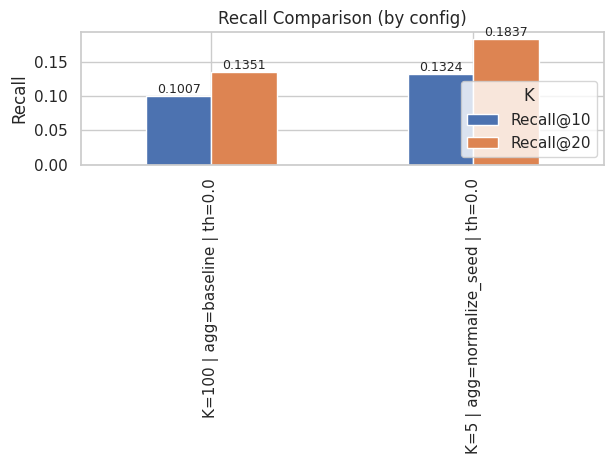

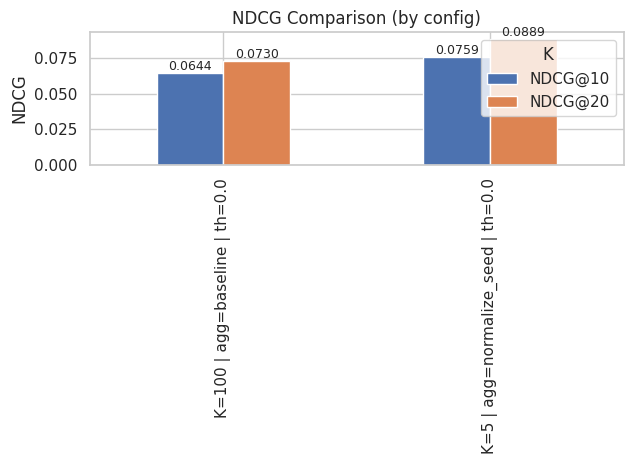

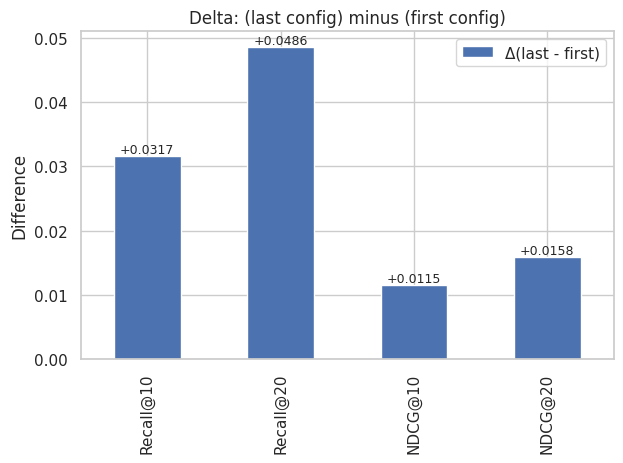

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1) 在這裡填你的不同參數設定結果（可 2 組以上）
#    label 請務必寫清楚：ITEM_K / aggregation / sim_threshold
# ============================================================
configs = [
    {
        "label": "K=100 | agg=baseline | th=0.0",
        "Recall@10": 0.100688,
        "NDCG@10":   0.064403,
        "Recall@20": 0.135084,
        "NDCG@20":   0.073023,
    },
    {
        "label": "K=5 | agg=normalize_seed | th=0.0",
        "Recall@10": 0.132374,
        "NDCG@10":   0.075888,
        "Recall@20": 0.183656,
        "NDCG@20":   0.088863,
    },
    # 之後你再多跑幾組就照樣新增 dict
    # {
    #     "label": "K=5 | agg=baseline | th=0.0",
    #     "Recall@10": ...,
    #     "NDCG@10":   ...,
    #     "Recall@20": ...,
    #     "NDCG@20":   ...,
    # },
]

df = pd.DataFrame(configs).set_index("label")
display(df)

# ============================================================
# 2) 畫圖小工具：bar chart + 在柱上標數字
# ============================================================
def plot_bar(df_part: pd.DataFrame, title: str, ylabel: str):
    ax = df_part.plot(kind="bar")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.legend(title="K")

    # 在每根柱上標數字
    for p in ax.patches:
        h = p.get_height()
        ax.annotate(f"{h:.4f}",
                    (p.get_x() + p.get_width()/2, h),
                    ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()

# ============================================================
# 3) Recall 圖（@10/@20）
# ============================================================
plot_bar(
    df[["Recall@10", "Recall@20"]],
    title="Recall Comparison (by config)",
    ylabel="Recall"
)

# ============================================================
# 4) NDCG 圖（@10/@20）
# ============================================================
plot_bar(
    df[["NDCG@10", "NDCG@20"]],
    title="NDCG Comparison (by config)",
    ylabel="NDCG"
)

# ============================================================
# 5) 差值圖：最後一組 - 第一組（看提升幅度）
#    你也可以改成任意兩組相減
# ============================================================
if len(df) >= 2:
    diff = (df.iloc[-1] - df.iloc[0]).to_frame(name="Δ(last - first)").T
    ax = diff[["Recall@10", "Recall@20", "NDCG@10", "NDCG@20"]].T.plot(kind="bar")
    ax.set_title("Delta: (last config) minus (first config)")
    ax.set_xlabel("")
    ax.set_ylabel("Difference")

    for p in ax.patches:
        h = p.get_height()
        ax.annotate(f"{h:+.4f}",
                    (p.get_x() + p.get_width()/2, h),
                    ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()


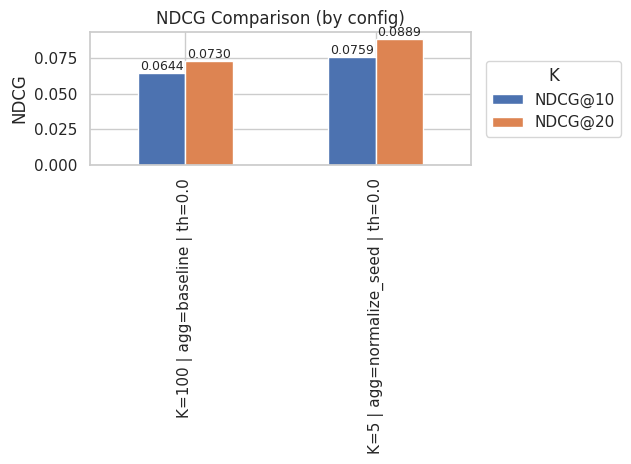

In [ ]:
ax = df[["NDCG@10", "NDCG@20"]].plot(kind="bar")
ax.set_title("NDCG Comparison (by config)")
ax.set_xlabel("")
ax.set_ylabel("NDCG")

# 👇 legend 移到右側圖外
ax.legend(title="K", loc="center left", bbox_to_anchor=(1.02, 0.5))

# 在柱上標數字
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{h:.4f}",
                (p.get_x() + p.get_width()/2, h),
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


#找出最佳組合

In [ ]:
# ============================================================
# ONE CELL: Build X_ui + Fit KNN(maxK=100) + Grid Search
# - If /content/train_encoded.parquet exists: load it (FAST, low RAM)
# - Else: stream-encode from train.csv using encoders (SLOW but works)
# Output: itemknn_grid_metrics.csv
# ============================================================

import os, gc, pickle
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

# -----------------------------
# (0) Paths (edit if needed)
# -----------------------------
TRAIN_CSV_PATH   = "/content/data/kkbox_datasets/train.csv"
MSNO_ENC_PATH    = "/content/msno_encoder.pkl"
SONG_ENC_PATH    = "/content/song_encoder.pkl"
CM_SMALL_PATH    = "/content/complete_members_small.csv"
TRAIN_ENC_PARQ   = "/content/train_encoded.parquet"   # recommended cache
CHUNKSIZE        = 2_000_000

# -----------------------------
# (1) Config
# -----------------------------
RANDOM_SEED = 42
MIN_POS_PER_USER = 2
RECO_N = 20
EVAL_KS = (10, 20)

ITEM_K_LIST = [5, 25, 50, 75, 100]
SIM_T_LIST  = [0.00, 0.01, 0.02, 0.05]
AGG_LIST    = ["baseline", "sim2", "normalize_seed", "pop_penalty"]
POP_ALPHA   = 0.5
MAX_ITEM_K  = 100

USE_MIN_ITEM_FREQ = False
MIN_ITEM_FREQ = 3

TOP_N_USERS = 5000
MIN_MEMBERSHIP_DAYS = 30

# -----------------------------
# (2) Helpers
# -----------------------------
def fit_item_knn(X_ui: csr_matrix, item_k: int = 200):
    X_iu = X_ui.T.tocsr()
    nn = NearestNeighbors(
        n_neighbors=item_k + 1,
        metric="cosine",
        algorithm="brute",
        n_jobs=-1
    )
    nn.fit(X_iu)
    distances, indices = nn.kneighbors(X_iu, return_distance=True)
    sims = 1.0 - distances
    neigh_items = indices[:, 1:]
    neigh_sims  = sims[:, 1:]
    return neigh_items, neigh_sims

def select_top_users_same_as_preprocess(train_encoded: pd.DataFrame,
                                        complete_members_small: pd.DataFrame,
                                        top_n_users: int = 5000,
                                        min_membership_days: int = 30) -> np.ndarray:
    play_count = train_encoded["msno_id"].value_counts()
    candidates = complete_members_small[complete_members_small["membership_days"] > min_membership_days].copy()
    candidates["play_count"] = candidates["msno_id"].map(play_count).fillna(0).astype(np.int32)
    top_users = (
        candidates.sort_values("play_count", ascending=False)
        .head(top_n_users)["msno_id"]
        .to_numpy(dtype=np.int32)
    )
    return top_users

def prepare_train_for_knn(train_subset: pd.DataFrame) -> pd.DataFrame:
    df = train_subset.loc[:, ["msno_id", "song_id", "target"]].copy()
    df = df[df["target"] == 1].drop(columns=["target"])
    df = df.drop_duplicates(["msno_id", "song_id"]).reset_index(drop=True)
    df["msno_id"] = df["msno_id"].astype(np.int32)
    df["song_id"] = df["song_id"].astype(np.int32)
    return df

def filter_items_by_min_freq(pos_df: pd.DataFrame, min_freq: int = 3) -> pd.DataFrame:
    item_counts = pos_df["song_id"].value_counts()
    keep_items = item_counts[item_counts >= min_freq].index
    filtered = pos_df[pos_df["song_id"].isin(keep_items)].copy()
    filtered.reset_index(drop=True, inplace=True)
    return filtered

def leave_one_out_split(pos_df: pd.DataFrame, min_pos_per_user: int = 2, seed: int = 42):
    rng = np.random.default_rng(seed)
    counts = pos_df["msno_id"].value_counts()
    eligible_users = counts[counts >= min_pos_per_user].index
    df = pos_df[pos_df["msno_id"].isin(eligible_users)].copy()

    train_rows, test_rows = [], []
    for u, g in df.groupby("msno_id", sort=False):
        items = g["song_id"].to_numpy()
        test_idx = rng.integers(0, len(items))
        test_item = items[test_idx]
        train_items = np.delete(items, test_idx)
        test_rows.append((u, test_item))
        for it in train_items:
            train_rows.append((u, it))

    train_split = pd.DataFrame(train_rows, columns=["msno_id", "song_id"])
    test_split  = pd.DataFrame(test_rows,  columns=["msno_id", "test_song_id"])
    return train_split, test_split

def build_index_maps(train_split: pd.DataFrame):
    unique_users = train_split["msno_id"].unique()
    unique_items = train_split["song_id"].unique()
    user2idx = {u: i for i, u in enumerate(unique_users)}
    item2idx = {it: j for j, it in enumerate(unique_items)}
    idx2user = np.array(unique_users, dtype=np.int32)
    idx2item = np.array(unique_items, dtype=np.int32)
    return user2idx, idx2user, item2idx, idx2item

def build_user_item_matrix(train_split: pd.DataFrame, user2idx, item2idx):
    rows = train_split["msno_id"].map(user2idx).to_numpy()
    cols = train_split["song_id"].map(item2idx).to_numpy()
    data = np.ones(len(train_split), dtype=np.float32)
    X_ui = csr_matrix((data, (rows, cols)), shape=(len(user2idx), len(item2idx)))
    return X_ui

def recommend_for_user_cfg(user_idx: int, X_ui, neigh_items, neigh_sims,
                           top_n: int = 20, sim_threshold: float = 0.0,
                           aggregation: str = "baseline",
                           item_pop: np.ndarray | None = None,
                           pop_alpha: float = 0.5, pop_min: int = 1):
    s, e = X_ui.indptr[user_idx], X_ui.indptr[user_idx + 1]
    user_items = X_ui.indices[s:e]
    if user_items.size == 0:
        return np.array([], dtype=np.int32), np.array([], dtype=np.float32)

    seen = set(user_items.tolist())
    scores = {}
    denom = float(user_items.size) if aggregation == "normalize_seed" else 1.0

    for it in user_items:
        for nb, sim in zip(neigh_items[it], neigh_sims[it]):
            if nb in seen:
                continue
            if sim <= sim_threshold:
                continue

            if aggregation == "baseline":
                add = float(sim)
            elif aggregation == "sim2":
                add = float(sim * sim)
            elif aggregation == "normalize_seed":
                add = float(sim) / denom
            elif aggregation == "pop_penalty":
                if item_pop is None:
                    raise ValueError("pop_penalty needs item_pop")
                pop = max(int(item_pop[nb]), pop_min)
                add = float(sim) / (pop ** pop_alpha)
            else:
                raise ValueError(f"Unknown aggregation: {aggregation}")

            if add <= 0:
                continue
            scores[nb] = scores.get(nb, 0.0) + add

    if not scores:
        return np.array([], dtype=np.int32), np.array([], dtype=np.float32)

    cand_items = np.fromiter(scores.keys(), dtype=np.int32)
    cand_scores = np.fromiter(scores.values(), dtype=np.float32)

    if cand_items.size > top_n:
        top_idx = np.argpartition(-cand_scores, top_n - 1)[:top_n]
        cand_items = cand_items[top_idx]
        cand_scores = cand_scores[top_idx]

    order = np.argsort(-cand_scores)
    return cand_items[order], cand_scores[order]

def evaluate_loou_cfg(test_split: pd.DataFrame, user2idx, item2idx, X_ui,
                      neigh_items, neigh_sims, eval_ks=(10, 20), reco_n=20,
                      sim_threshold: float = 0.0, aggregation: str = "baseline",
                      item_pop: np.ndarray | None = None, pop_alpha: float = 0.5):
    hits = {k: 0 for k in eval_ks}
    ndcgs = {k: 0.0 for k in eval_ks}
    n_eval = 0

    for row in test_split.itertuples(index=False):
        u = row.msno_id
        t = row.test_song_id
        if u not in user2idx:
            continue
        if t not in item2idx:
            continue

        uidx = user2idx[u]
        tidx = item2idx[t]
        rec_items, _ = recommend_for_user_cfg(
            uidx, X_ui, neigh_items, neigh_sims,
            top_n=reco_n, sim_threshold=sim_threshold,
            aggregation=aggregation, item_pop=item_pop, pop_alpha=pop_alpha
        )

        n_eval += 1
        if rec_items.size == 0:
            continue

        pos = np.where(rec_items == tidx)[0]
        rank = int(pos[0]) + 1 if pos.size > 0 else None

        for k in eval_ks:
            if rank is not None and rank <= k:
                hits[k] += 1
                ndcgs[k] += 1.0 / np.log2(rank + 1)

    out = {"Users": n_eval, "Reco_N": reco_n, "Item_K": neigh_items.shape[1]}
    for k in eval_ks:
        out[f"Recall@{k}"] = hits[k] / n_eval if n_eval else 0.0
        out[f"Precision@{k}"] = hits[k] / (n_eval * k) if n_eval else 0.0
        out[f"NDCG@{k}"] = ndcgs[k] / n_eval if n_eval else 0.0
    return out

# -----------------------------
# (3) Load train_encoded (parquet) OR stream-encode
# -----------------------------
if os.path.exists(TRAIN_ENC_PARQ):
    print(f"==> Loading cached train_encoded from: {TRAIN_ENC_PARQ}")
    train_encoded = pd.read_parquet(TRAIN_ENC_PARQ)
else:
    print("==> No cached train_encoded.parquet. Streaming encode from train.csv ...")
    with open(MSNO_ENC_PATH, "rb") as f:
        msno_le = pickle.load(f)
    with open(SONG_ENC_PATH, "rb") as f:
        song_le = pickle.load(f)

    known_msno = set(msno_le.classes_)
    known_song = set(song_le.classes_)

    out_parts = []
    total_in = 0
    total_keep = 0

    for chunk in pd.read_csv(TRAIN_CSV_PATH, usecols=["msno","song_id","target"], chunksize=CHUNKSIZE):
        total_in += len(chunk)

        chunk = chunk[chunk["msno"].isin(known_msno)]
        chunk = chunk[chunk["song_id"].isin(known_song)]
        if len(chunk) == 0:
            continue

        chunk["msno_id"] = msno_le.transform(chunk["msno"]).astype(np.int32)
        chunk["song_id"] = song_le.transform(chunk["song_id"]).astype(np.int32)
        chunk["target"]  = chunk["target"].astype(np.int8)
        chunk = chunk[["msno_id","song_id","target"]]

        out_parts.append(chunk)
        total_keep += len(chunk)

        del chunk
        gc.collect()

    if not out_parts:
        raise ValueError("stream encode 後沒有任何資料通過白名單過濾，請檢查 encoder / train.csv 欄位。")

    train_encoded = pd.concat(out_parts, ignore_index=True)
    print(f"讀入原始筆數：{total_in:,}")
    print(f"保留筆數：{total_keep:,}")
    print("train_encoded shape:", train_encoded.shape)

    # 建議存 parquet，之後超快
    print(f"==> Saving cache to: {TRAIN_ENC_PARQ}")
    train_encoded.to_parquet(TRAIN_ENC_PARQ, index=False)

# -----------------------------
# (4) Top5000 user subset
# -----------------------------
complete_members_small = pd.read_csv(CM_SMALL_PATH)
top_users = select_top_users_same_as_preprocess(train_encoded, complete_members_small,
                                                top_n_users=TOP_N_USERS,
                                                min_membership_days=MIN_MEMBERSHIP_DAYS)
train_subset = train_encoded[train_encoded["msno_id"].isin(top_users)].copy()
train_subset.reset_index(drop=True, inplace=True)

print("\n========== [0] Top5000 Subset ==========")
print("train_subset rows:", len(train_subset))
print("unique users:", train_subset["msno_id"].nunique())
print("unique songs:", train_subset["song_id"].nunique())

del train_encoded
gc.collect()

# -----------------------------
# (5) pos_df + optional min item freq
# -----------------------------
print("\n========== [1] pos_df ==========")
pos_df = prepare_train_for_knn(train_subset)
print("pos_df rows:", len(pos_df))
print("pos_df users:", pos_df["msno_id"].nunique())
print("pos_df songs:", pos_df["song_id"].nunique())

del train_subset
gc.collect()

if USE_MIN_ITEM_FREQ:
    print(f"\n========== [2] Filter items min_freq={MIN_ITEM_FREQ} ==========")
    pos_df = filter_items_by_min_freq(pos_df, MIN_ITEM_FREQ)
    print("after filter rows:", len(pos_df))
    print("after filter songs:", pos_df["song_id"].nunique())

# -----------------------------
# (6) LOO split
# -----------------------------
print("\n========== [3] Leave-One-Out ==========")
train_split, test_split = leave_one_out_split(pos_df, min_pos_per_user=MIN_POS_PER_USER, seed=RANDOM_SEED)
print("train_split:", len(train_split))
print("test_split users:", len(test_split))

del pos_df
gc.collect()

# -----------------------------
# (7) X_ui
# -----------------------------
print("\n========== [4] Build X_ui ==========")
user2idx, idx2user, item2idx, idx2item = build_index_maps(train_split)
X_ui = build_user_item_matrix(train_split, user2idx, item2idx)
print(f"X_ui shape: {X_ui.shape[0]:,} users x {X_ui.shape[1]:,} items")
print("X_ui nnz:", X_ui.nnz)

del train_split
gc.collect()

# item popularity
print("==> Building item_pop ...")
X_iu_csc = X_ui.T.tocsc()
item_pop = np.diff(X_iu_csc.indptr).astype(np.int32)
del X_iu_csc
gc.collect()

# -----------------------------
# (8) Fit KNN once (maxK=100)
# -----------------------------
print("\n========== [5] Fit item-KNN once ==========")
neigh_items_all, neigh_sims_all = fit_item_knn(X_ui, item_k=MAX_ITEM_K)
print("neigh_items_all:", neigh_items_all.shape)

# -----------------------------
# (9) Grid search
# -----------------------------
print("\n========== [6] Grid Search ==========")
rows = []
for k in ITEM_K_LIST:
    neigh_items = neigh_items_all[:, :k]
    neigh_sims  = neigh_sims_all[:, :k]

    for sim_t in SIM_T_LIST:
        for agg in AGG_LIST:
            res = evaluate_loou_cfg(
                test_split=test_split,
                user2idx=user2idx,
                item2idx=item2idx,
                X_ui=X_ui,
                neigh_items=neigh_items,
                neigh_sims=neigh_sims,
                eval_ks=EVAL_KS,
                reco_n=RECO_N,
                sim_threshold=sim_t,
                aggregation=agg,
                item_pop=item_pop,
                pop_alpha=POP_ALPHA
            )
            res.update({
                "Model": f"ItemKNN({agg})",
                "Split": "LOO(pos-only)",
                "sim_threshold": sim_t,
                "pop_alpha": POP_ALPHA if agg == "pop_penalty" else np.nan
            })
            rows.append(res)
            print(f"k={k:3d} | sim_t={sim_t:.2f} | agg={agg:14s} | R@10={res['Recall@10']:.5f} | N@10={res['NDCG@10']:.5f}")

metrics_grid_df = pd.DataFrame(rows)
metrics_grid_df.to_csv("itemknn_grid_metrics.csv", index=False, encoding="utf-8-sig")
print("\n✅ 已輸出：itemknn_grid_metrics.csv")

best = metrics_grid_df.sort_values(["Recall@10","NDCG@10"], ascending=False).head(20)
print("\n===== Top 20 configs (by Recall@10 then NDCG@10) =====")
print(best[["Model","Item_K","sim_threshold","pop_alpha","Recall@10","NDCG@10","Recall@20","NDCG@20","Users"]])

==> Loading cached train_encoded from: /content/train_encoded.parquet

========== [0] Top5000 Subset ==========
train_subset rows: 3262169
unique users: 5000
unique songs: 246728

========== [1] pos_df ==========
pos_df rows: 1680693
pos_df users: 5000
pos_df songs: 151639

========== [3] Leave-One-Out ==========
train_split: 1675693
test_split users: 5000

========== [4] Build X_ui ==========
X_ui shape: 5,000 users x 151,436 items
X_ui nnz: 1675693
==> Building item_pop ...

========== [5] Fit item-KNN once ==========


KeyboardInterrupt: 

In [ ]:
import numpy as np, gc

print("X_ui shape:", X_ui.shape)  # (n_users, n_items) = (5000, 151412)

# 1) 先看看你現在 item_pop 到底是什麼
if "item_pop" in globals():
    try:
        print("current item_pop len:", len(item_pop))
    except Exception as e:
        print("item_pop exists but cannot len():", e)
else:
    print("item_pop not found yet")

# 2) 強制重建：item popularity = 每個 item 的 column nnz
#    用 X_ui.tocsc() 最直覺、最不會搞反
X_ui_csc = X_ui.tocsc()
item_pop = np.diff(X_ui_csc.indptr).astype(np.int32)  # len must be n_items
del X_ui_csc
gc.collect()

print("FIXED item_pop len:", len(item_pop), " expected n_items:", X_ui.shape[1])
assert len(item_pop) == X_ui.shape[1], "item_pop 長度不等於 n_items，代表你又算反了"

# 3) 快速驗證：隨便抽一些 nb 看是否可索引
test_nbs = [0, 1, 10, 6005, X_ui.shape[1]-1]
print("pop samples:", [(nb, int(item_pop[nb])) for nb in test_nbs])

# 4) 快速跑一個 config（pop_penalty）確保不會爆
k = 5
sim_t = 0.00
neigh_items = neigh_items_all[:, :k]
neigh_sims  = neigh_sims_all[:, :k]

res_test = evaluate_loou_cfg(
    test_split=test_split,
    user2idx=user2idx,
    item2idx=item2idx,
    X_ui=X_ui,
    neigh_items=neigh_items,
    neigh_sims=neigh_sims,
    eval_ks=EVAL_KS,
    reco_n=RECO_N,
    sim_threshold=sim_t,
    aggregation="pop_penalty",
    item_pop=item_pop,
    pop_alpha=POP_ALPHA
)
print("✅ pop_penalty sanity check OK:", res_test)


X_ui shape: (5000, 151436)
current item_pop len: 5000
FIXED item_pop len: 151436  expected n_items: 151436
pop samples: [(0, 1), (1, 2), (10, 417), (6005, 293), (151435, 1)]
✅ pop_penalty sanity check OK: {'Users': 4797, 'Reco_N': 20, 'Item_K': 5, 'Recall@10': 0.013967062747550553, 'Precision@10': 0.0013967062747550552, 'NDCG@10': np.float64(0.00761998898202291), 'Recall@20': 0.02272253491765687, 'Precision@20': 0.0011361267458828434, 'NDCG@20': np.float64(0.009866408327369814)}


In [ ]:
# ===== Patch: rebuild item_pop correctly (len = n_items) =====
import numpy as np, gc

print("X_ui shape:", X_ui.shape)  # should be (n_users, n_items)

# Correct item popularity: column nnz -> use CSC
X_ui_csc = X_ui.tocsc()
item_pop = np.diff(X_ui_csc.indptr).astype(np.int32)  # len = n_items
del X_ui_csc
gc.collect()

print("item_pop len:", len(item_pop), " expected n_items:", X_ui.shape[1])
print("item_pop sample:", item_pop[:10])


X_ui shape: (5000, 151436)
item_pop len: 151436  expected n_items: 151436
item_pop sample: [   1    2    1 1044 3308  651  206  199  390  172]


In [ ]:
import numpy as np
import pandas as pd

# 保護：確定你目前 item_pop 是正確的（len = n_items）
assert len(item_pop) == X_ui.shape[1], f"item_pop len={len(item_pop)} but n_items={X_ui.shape[1]}"

# 你要測的 grid
ITEM_K_LIST = [5, 25, 50, 75, 100]
SIM_T_LIST  = [0.00, 0.01, 0.02, 0.05]
RECO_N      = 20
EVAL_KS     = (10, 20)
POP_ALPHA   = 0.5

# aggregation 清單：把 pop_penalty 拆成兩種（更合理）
AGG_LIST = ["baseline", "sim2", "normalize_seed", "pop_pow", "pop_log"]

def recommend_for_user_cfg2(
    user_idx: int,
    X_ui,
    neigh_items,
    neigh_sims,
    top_n: int = 20,
    sim_threshold: float = 0.0,
    aggregation: str = "baseline",
    item_pop: np.ndarray | None = None,
    pop_alpha: float = 0.5,
    pop_min: int = 1
):
    s, e = X_ui.indptr[user_idx], X_ui.indptr[user_idx + 1]
    user_items = X_ui.indices[s:e]
    if user_items.size == 0:
        return np.array([], dtype=np.int32), np.array([], dtype=np.float32)

    seen = set(user_items.tolist())
    scores = {}

    denom = float(user_items.size) if aggregation == "normalize_seed" else 1.0

    for it in user_items:
        for nb, sim in zip(neigh_items[it], neigh_sims[it]):
            if nb in seen:
                continue
            if sim <= sim_threshold:
                continue

            if aggregation == "baseline":
                add = float(sim)
            elif aggregation == "sim2":
                add = float(sim * sim)
            elif aggregation == "normalize_seed":
                add = float(sim) / denom
            elif aggregation in ("pop_pow", "pop_log"):
                if item_pop is None:
                    raise ValueError("pop_* needs item_pop")
                pop = max(int(item_pop[nb]), pop_min)

                if aggregation == "pop_pow":
                    # 原本你那種：sim / pop^alpha（偏硬）
                    add = float(sim) / (pop ** pop_alpha)
                else:
                    # 建議：sim / log1p(pop)^alpha（溫和很多）
                    add = float(sim) / (np.log1p(pop) ** pop_alpha)
            else:
                raise ValueError(f"Unknown aggregation: {aggregation}")

            if add <= 0:
                continue
            scores[nb] = scores.get(nb, 0.0) + add

    if not scores:
        return np.array([], dtype=np.int32), np.array([], dtype=np.float32)

    cand_items = np.fromiter(scores.keys(), dtype=np.int32)
    cand_scores = np.fromiter(scores.values(), dtype=np.float32)

    if cand_items.size > top_n:
        top_idx = np.argpartition(-cand_scores, top_n - 1)[:top_n]
        cand_items = cand_items[top_idx]
        cand_scores = cand_scores[top_idx]

    order = np.argsort(-cand_scores)
    return cand_items[order], cand_scores[order]

def evaluate_loou_cfg2(
    test_split: pd.DataFrame,
    user2idx,
    item2idx,
    X_ui,
    neigh_items,
    neigh_sims,
    eval_ks=(10, 20),
    reco_n=20,
    sim_threshold: float = 0.0,
    aggregation: str = "baseline",
    item_pop: np.ndarray | None = None,
    pop_alpha: float = 0.5
):
    hits = {k: 0 for k in eval_ks}
    ndcgs = {k: 0.0 for k in eval_ks}
    n_eval = 0

    for row in test_split.itertuples(index=False):
        u = row.msno_id
        t = row.test_song_id
        if u not in user2idx:
            continue
        if t not in item2idx:
            continue

        uidx = user2idx[u]
        tidx = item2idx[t]

        rec_items, _ = recommend_for_user_cfg2(
            uidx, X_ui, neigh_items, neigh_sims,
            top_n=reco_n,
            sim_threshold=sim_threshold,
            aggregation=aggregation,
            item_pop=item_pop,
            pop_alpha=pop_alpha
        )

        n_eval += 1
        if rec_items.size == 0:
            continue

        pos = np.where(rec_items == tidx)[0]
        rank = int(pos[0]) + 1 if pos.size > 0 else None

        for k in eval_ks:
            if rank is not None and rank <= k:
                hits[k] += 1
                ndcgs[k] += 1.0 / np.log2(rank + 1)

    out = {"Users": n_eval, "Reco_N": reco_n, "Item_K": neigh_items.shape[1]}
    for k in eval_ks:
        out[f"Recall@{k}"] = hits[k] / n_eval if n_eval else 0.0
        out[f"Precision@{k}"] = hits[k] / (n_eval * k) if n_eval else 0.0
        out[f"NDCG@{k}"] = ndcgs[k] / n_eval if n_eval else 0.0
    return out

print("==> Re-running grid search with safe pop penalties ...")
rows = []
for k in ITEM_K_LIST:
    neigh_items = neigh_items_all[:, :k]
    neigh_sims  = neigh_sims_all[:, :k]

    for sim_t in SIM_T_LIST:
        for agg in AGG_LIST:
            res = evaluate_loou_cfg2(
                test_split=test_split,
                user2idx=user2idx,
                item2idx=item2idx,
                X_ui=X_ui,
                neigh_items=neigh_items,
                neigh_sims=neigh_sims,
                eval_ks=EVAL_KS,
                reco_n=RECO_N,
                sim_threshold=sim_t,
                aggregation=agg,
                item_pop=item_pop,
                pop_alpha=POP_ALPHA
            )
            res.update({
                "Model": f"ItemKNN({agg})",
                "Split": "LOO(pos-only)",
                "sim_threshold": sim_t,
                "pop_alpha": POP_ALPHA if agg in ("pop_pow","pop_log") else np.nan
            })
            rows.append(res)
            print(f"k={k:3d} | sim_t={sim_t:.2f} | agg={agg:12s} | R@10={res['Recall@10']:.5f} | N@10={res['NDCG@10']:.5f}")

metrics_grid_df = pd.DataFrame(rows)
metrics_grid_df.to_csv("itemknn_grid_metrics.csv", index=False, encoding="utf-8-sig")
print("\n✅ 已輸出：itemknn_grid_metrics.csv")

best = metrics_grid_df.sort_values(["Recall@10","NDCG@10"], ascending=False).head(20)
print("\n===== Top 20 configs (by Recall@10 then NDCG@10) =====")
print(best[["Model","Item_K","sim_threshold","pop_alpha","Recall@10","NDCG@10","Recall@20","NDCG@20","Users"]])


==> Re-running grid search with safe pop penalties ...
k=  5 | sim_t=0.00 | agg=baseline     | R@10=0.13237 | N@10=0.07589
k=  5 | sim_t=0.00 | agg=sim2         | R@10=0.12570 | N@10=0.07287
k=  5 | sim_t=0.00 | agg=normalize_seed | R@10=0.13237 | N@10=0.07589


KeyboardInterrupt: 

In [ ]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT_DIR = "/content/itemknn_plots"
os.makedirs(OUT_DIR, exist_ok=True)

# 讀資料：優先用你剛剛跑完的 metrics_grid_df；沒有才讀 csv
if "metrics_grid_df" in globals() and isinstance(metrics_grid_df, pd.DataFrame) and len(metrics_grid_df) > 0:
    df = metrics_grid_df.copy()
    print("Using metrics_grid_df from memory")
else:
    df = pd.read_csv("/content/itemknn_grid_metrics.csv")
    print("Loaded /content/itemknn_grid_metrics.csv")

# 解析 agg 名稱
def parse_agg(model_str):
    m = re.search(r"ItemKNN\((.*?)\)", str(model_str))
    return m.group(1) if m else str(model_str)

df["agg"] = df["Model"].apply(parse_agg)

# 型態處理
num_cols = ["Item_K","sim_threshold","Recall@10","NDCG@10","Recall@20","NDCG@20"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.dropna(subset=["Item_K","sim_threshold","Recall@10","NDCG@10"]).copy()

df = df.sort_values(["agg","Item_K","sim_threshold"]).reset_index(drop=True)

print("Aggs:", sorted(df["agg"].unique()))
print("Item_K:", sorted(df["Item_K"].unique()))
print("sim_threshold:", sorted(df["sim_threshold"].unique()))
print("Rows:", len(df))

def savefig(fname):
    path = os.path.join(OUT_DIR, fname)
    plt.savefig(path, dpi=170, bbox_inches="tight")
    plt.close()
    print("Saved:", path)

# -------------------------
# (A) Top configs table (save)
# -------------------------
ranked = df.sort_values(["Recall@10","NDCG@10","Recall@20","NDCG@20"], ascending=False).reset_index(drop=True)
ranked.to_csv(os.path.join(OUT_DIR, "ranked_all_configs.csv"), index=False, encoding="utf-8-sig")
print("Saved ranked table:", os.path.join(OUT_DIR, "ranked_all_configs.csv"))

# -------------------------
# (B) Best-per-agg bar charts
# -------------------------
best_per_agg = (
    df.sort_values(["agg","Recall@10","NDCG@10"], ascending=[True, False, False])
      .groupby("agg", as_index=False)
      .head(1)
      .reset_index(drop=True)
)

plt.figure()
plt.bar(best_per_agg["agg"], best_per_agg["Recall@10"])
plt.xticks(rotation=45, ha="right")
plt.title("Best Recall@10 per aggregation (best Item_K & sim_threshold)")
plt.ylabel("Recall@10")
savefig("bar_best_recall10_per_agg.png")

plt.figure()
plt.bar(best_per_agg["agg"], best_per_agg["NDCG@10"])
plt.xticks(rotation=45, ha="right")
plt.title("Best NDCG@10 per aggregation (best Item_K & sim_threshold)")
plt.ylabel("NDCG@10")
savefig("bar_best_ndcg10_per_agg.png")

# -------------------------
# (C) Heatmaps (Item_K x sim_threshold) for each agg and each metric
# -------------------------
metrics = ["Recall@10","NDCG@10","Recall@20","NDCG@20"]
for agg in sorted(df["agg"].unique()):
    sub = df[df["agg"] == agg].copy()
    if sub.empty:
        continue

    for metric in metrics:
        piv = sub.pivot_table(index="Item_K", columns="sim_threshold", values=metric, aggfunc="mean")
        piv = piv.sort_index().sort_index(axis=1)

        arr = piv.to_numpy()
        plt.figure()
        im = plt.imshow(arr, aspect="auto", interpolation="nearest")
        plt.colorbar(im)
        plt.title(f"{metric} heatmap | agg={agg}")
        plt.xlabel("sim_threshold")
        plt.ylabel("Item_K")
        plt.xticks(np.arange(piv.shape[1]), [f"{x:.2f}" for x in piv.columns.tolist()])
        plt.yticks(np.arange(piv.shape[0]), piv.index.tolist())
        savefig(f"heatmap_{metric.replace('@','at')}_agg_{agg}.png")

# -------------------------
# (D) Lines: metric vs Item_K, one line per sim_threshold (for each agg)
# -------------------------
for agg in sorted(df["agg"].unique()):
    sub = df[df["agg"] == agg].copy()
    if sub.empty:
        continue

    for metric in ["Recall@10","NDCG@10","Recall@20","NDCG@20"]:
        plt.figure()
        for sim_t in sorted(sub["sim_threshold"].unique()):
            sub2 = sub[sub["sim_threshold"] == sim_t].sort_values("Item_K")
            plt.plot(sub2["Item_K"], sub2[metric], marker="o", label=f"sim_t={sim_t:.2f}")
        plt.title(f"{metric} vs Item_K | agg={agg}")
        plt.xlabel("Item_K")
        plt.ylabel(metric)
        plt.legend()
        savefig(f"line_{metric.replace('@','at')}_vs_itemk_agg_{agg}.png")

# -------------------------
# (E) Compare aggs: for each sim_threshold, plot metric vs Item_K (one line per agg)
# -------------------------
for sim_t in sorted(df["sim_threshold"].unique()):
    sub = df[df["sim_threshold"] == sim_t].copy()
    if sub.empty:
        continue

    for metric in ["Recall@10","NDCG@10","Recall@20","NDCG@20"]:
        plt.figure()
        for agg in sorted(sub["agg"].unique()):
            sub2 = sub[sub["agg"] == agg].sort_values("Item_K")
            plt.plot(sub2["Item_K"], sub2[metric], marker="o", label=agg)
        plt.title(f"{metric} vs Item_K | sim_threshold={sim_t:.2f}")
        plt.xlabel("Item_K")
        plt.ylabel(metric)
        plt.legend()
        savefig(f"compare_aggs_{metric.replace('@','at')}_simt_{sim_t:.2f}.png")

# -------------------------
# (F) Scatter: Recall@10 vs NDCG@10 colored by agg (separate plots per agg to avoid manual colors)
# -------------------------
for agg in sorted(df["agg"].unique()):
    sub = df[df["agg"] == agg].copy()
    if sub.empty:
        continue
    plt.figure()
    plt.scatter(sub["Recall@10"], sub["NDCG@10"])
    plt.title(f"Tradeoff scatter | agg={agg}")
    plt.xlabel("Recall@10")
    plt.ylabel("NDCG@10")
    savefig(f"scatter_recall10_vs_ndcg10_agg_{agg}.png")

# All-in-one scatter (no colors specified)
plt.figure()
plt.scatter(df["Recall@10"], df["NDCG@10"])
plt.title("Tradeoff scatter (all configs): Recall@10 vs NDCG@10")
plt.xlabel("Recall@10")
plt.ylabel("NDCG@10")
savefig("scatter_recall10_vs_ndcg10_all.png")

print("\n✅ Done. All plots saved to:", OUT_DIR)
print("You can download the entire folder from Colab file browser.")


In [ ]:
!zip -r /content/itemknn_plots.zip /content/itemknn_plots

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# 矩陣分解 MF

In [ ]:
df_pos_check = train[train['target'] == 1].copy()
user_counts = df_pos_check.groupby('msno_id').size()
valid_users = user_counts[user_counts >= 2].index
df_filtered = train[train['msno_id'].isin(valid_users)].copy()

print(f"篩選互動數 >= 2 的使用者後，剩餘資料筆數: {len(df_filtered)}")

篩選互動數 >= 2 的使用者後，剩餘資料筆數: 3262169


In [ ]:
unique_users = df_filtered['msno_id'].unique()
useridx = {old_id: new_id for new_id, old_id in enumerate(unique_users)}

unique_songs = df_filtered['song_id'].unique()
itemidx = {old_id: new_id for new_id, old_id in enumerate(unique_songs)}

df_filtered['msno_idx'] = df_filtered['msno_id'].map(useridx)
df_filtered['song_idx'] = df_filtered['song_id'].map(itemidx)

num_users = len(useridx)
num_songs = len(itemidx)
print(f"使用者 index: {num_users}, 歌曲 index: {num_songs}")

使用者 index: 5000, 歌曲 index: 246708


In [ ]:
df_positives = df_filtered[df_filtered['target'] == 1].copy()

df_positives = df_positives.sample(frac=1, random_state=42).sort_values('msno_idx')
test_indices = df_positives.groupby('msno_idx').tail(1).index

df_test = df_positives.loc[test_indices].copy()
df_train = df_filtered.drop(test_indices).copy()

df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"訓練集筆數: {len(df_train)}")
print(f"測試集筆數: {len(df_test)}")

X_train_full = df_train[['msno_idx', 'song_idx']].values
y_train_full = df_train['target'].values

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1, random_state=42
)

訓練集筆數: 3257169
測試集筆數: 5000


In [ ]:
# 基礎模型(暫時留著而已)(不要用這個)
def build_mf_model(num_users, num_items, embedding_dim=64):
    user_input = layers.Input(shape=(1,), name='user_input')
    item_input = layers.Input(shape=(1,), name='song_input')

    # Embedding 層 (將整數 ID 轉為向量)
    user_embedding = layers.Embedding(input_dim=num_users, output_dim=embedding_dim, name='user_embedding')(user_input)
    item_embedding = layers.Embedding(input_dim=num_items, output_dim=embedding_dim, name='song_embedding')(item_input)

    # 扁平化 (將 (batch, 1, 32) 轉為 (batch, 32))
    user_vec = layers.Flatten()(user_embedding)
    item_vec = layers.Flatten()(item_embedding)

    dot_product = layers.Dot(axes=1, name='dot_product')([user_vec, item_vec])

    output = layers.Activation('sigmoid')(dot_product)

    model = models.Model(inputs=[user_input, item_input], outputs=output)
    return model

In [ ]:
# 基礎模型(暫時留著而已)
model = build_mf_model(num_users, num_songs, embedding_dim=64)

# 預設閾值是 0.5
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ song_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 64)     │    896,704 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ song_embedding      │ (None, 1, 64)     │ 146,942,0… │ song_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 64)        │          0 │ user_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 64)        │          0 │ song_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_product (Dot)   │ (None, 1)         │          0 │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1)         │          0 │ dot_product[0][0] │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 147,838,720 (563.96 MB)

 Trainable params: 147,838,720 (563.96 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 基礎模型(暫時留著而已)
history = model.fit(
    x=[X_train[:, 0], X_train[:, 1]],
    y=y_train,
    batch_size=2048,
    epochs=5,
    validation_data=([X_val[:, 0], X_val[:, 1]], y_val),
    verbose=1
)
model.save('my_mf_model.h5')
print("模型已存檔！")

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/tensorflow/python/framework/indexed_slices.py:446: UserWarning: Converting sparse IndexedSlices to a dense Tensor with 146942016 elements. This may consume a large amount of memory.
  warnings.warn(


1115/1115 ━━━━━━━━━━━━━━━━━━━━ 42s 34ms/step - accuracy: 0.5175 - auc: 0.5282 - loss: 0.6911 - precision: 0.5300 - recall: 0.5474 - val_accuracy: 0.5982 - val_auc: 0.6620 - val_loss: 0.6570 - val_precision: 0.5857 - val_recall: 0.7463
Epoch 2/5
1115/1115 ━━━━━━━━━━━━━━━━━━━━ 34s 30ms/step - accuracy: 0.7064 - auc: 0.7426 - loss: 0.6342 - precision: 0.6793 - recall: 0.8152 - val_accuracy: 0.6415 - val_auc: 0.7081 - val_loss: 0.6253 - val_precision: 0.6336 - val_recall: 0.7177
Epoch 3/5
1115/1115 ━━━━━━━━━━━━━━━━━━━━ 35s 31ms/step - accuracy: 0.7635 - auc: 0.8166 - loss: 0.5653 - precision: 0.7488 - recall: 0.8145 - val_accuracy: 0.6521 - val_auc: 0.7199 - val_loss: 0.6133 - val_precision: 0.6486 - val_recall: 0.7057
Epoch 4/5
1115/1115 ━━━━━━━━━━━━━━━━━━━━ 34s 31ms/step - accuracy: 0.7936 - auc: 0.8636 - loss: 0.4991 - precision: 0.7843 - recall: 0.8272 - val_accuracy: 0.6559 - val_auc: 0.7231 - val_loss: 0.6116 - val_precision: 0.6544 - val_recall: 0.7008
Epoch 5/5
1115/1115 ━━━━━━━━━━

模型已存檔！


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

# 有調整項的模型(用這個)
def build_improved_mf_model(num_users, num_items, embedding_dim=128):
    user_input = layers.Input(shape=(1,), name='user_input')
    item_input = layers.Input(shape=(1,), name='song_input')

    # 加入 L2 正規化
    user_embedding = layers.Embedding(
        input_dim=num_users,
        output_dim=embedding_dim,
        embeddings_regularizer=regularizers.l2(1e-6),
        name='user_embedding'
    )(user_input)

    item_embedding = layers.Embedding(
        input_dim=num_items,
        output_dim=embedding_dim,
        embeddings_regularizer=regularizers.l2(1e-6),
        name='song_embedding'
    )(item_input)

    user_bias = layers.Embedding(
        input_dim=num_users,
        output_dim=1,
        name='user_bias'
    )(user_input)

    item_bias = layers.Embedding(
        input_dim=num_items,
        output_dim=1,
        name='song_bias'
    )(item_input)

    user_vec = layers.Flatten()(user_embedding)
    item_vec = layers.Flatten()(item_embedding)
    u_bias = layers.Flatten()(user_bias)
    i_bias = layers.Flatten()(item_bias)

    dot_product = layers.Dot(axes=1, name='dot_product')([user_vec, item_vec])

    x = layers.Add()([dot_product, u_bias, i_bias])

    output = layers.Activation('sigmoid')(x)

    model = models.Model(inputs=[user_input, item_input], outputs=output)
    return model

model_improved = build_improved_mf_model(num_users, num_songs, embedding_dim=128)

model_improved.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

model_improved.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ song_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 128)    │    640,000 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ song_embedding      │ (None, 1, 128)    │ 31,578,624 │ song_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_15          │ (None, 128)       │          0 │ user_embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_16          │ (None, 128)       │          0 │ song_embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_bias           │ (None, 1, 1)      │      5,000 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ song_bias           │ (None, 1, 1)      │    246,708 │ song_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_product (Dot)   │ (None, 1)         │          0 │ flatten_15[0][0], │
│                     │                   │            │ flatten_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_17          │ (None, 1)         │          0 │ user_bias[0][0]   │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_18          │ (None, 1)         │          0 │ song_bias[0][0]   │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 1)         │          0 │ dot_product[0][0… │
│                     │                   │            │ flatten_17[0][0], │
│                     │                   │            │ flatten_18[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 1)         │          0 │ add_3[0][0]       │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 32,470,332 (123.86 MB)

 Trainable params: 32,470,332 (123.86 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 有調整項的模型(用這個)
history = model_improved.fit(
    x=[X_train[:, 0], X_train[:, 1]],
    y=y_train,
    batch_size=2048,
    epochs=10,
    validation_data=([X_val[:, 0], X_val[:, 1]], y_val),
    verbose=1
)

Epoch 1/10
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.6089 - auc: 0.6542 - loss: 0.6841 - precision: 0.6070 - recall: 0.6765 - val_accuracy: 0.6652 - val_auc: 0.7257 - val_loss: 0.6317 - val_precision: 0.6615 - val_recall: 0.7145
Epoch 2/10
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.6882 - auc: 0.7524 - loss: 0.6166 - precision: 0.6876 - recall: 0.7224 - val_accuracy: 0.6799 - val_auc: 0.7448 - val_loss: 0.6169 - val_precision: 0.6861 - val_recall: 0.6956
Epoch 3/10
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.7158 - auc: 0.7870 - loss: 0.5915 - precision: 0.7230 - recall: 0.7258 - val_accuracy: 0.6864 - val_auc: 0.7534 - val_loss: 0.6154 - val_precision: 0.6958 - val_recall: 0.6932
Epoch 4/10
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.7414 - auc: 0.8171 - loss: 0.5724 - precision: 0.7509 - recall: 0.7442 - val_accuracy: 0.6910 - val_auc: 0.7596 - val_loss: 0.6185 - val_precision: 0.7021 - val_recall: 0.6933
Epoch 5/10
1432/

In [ ]:
# Classification 的評估標準 (不適用top-k推薦)
from sklearn.metrics import classification_report, confusion_matrix

y_pred_prob = model_improved.predict([X_test[:, 0], X_test[:, 1]], batch_size=2048)
y_pred = (y_pred_prob >= 0.5).astype(int) # 如果模型預測機率 >= 0.5 視為會聽 (1)，否則為不聽 (0)

print("\n--- Classification Report (詳細報表) ---")
print(classification_report(y_test, y_pred))

print("\n--- Confusion Matrix (混淆矩陣) ---")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\n矩陣解讀:")
print(f"預測 0 且實際 0 (TN): {cm[0][0]}")
print(f"預測 1 但實際 0 (FP): {cm[0][1]}")
print(f"預測 0 但實際 1 (FN): {cm[1][0]}")
print(f"預測 1 且實際 1 (TP): {cm[1][1]}")

NameError: name 'X_test' is not defined

In [ ]:
import math
from tqdm import tqdm

In [ ]:
#舊版 (跳過)
def evaluate_mf_for_comparison(model, df_test, all_song_ids, eval_ks=(10, 20)):
    pos_test_data = df_test[df_test['target'] == 1].copy()
    test_users = pos_test_data['msno_id'].unique()

    user_pos_dict = pos_test_data.groupby('msno_id')['song_id'].apply(list).to_dict()

    # 初始化
    metrics = {k: {"hits": 0, "ndcg": 0.0} for k in eval_ks}
    n_eval = len(test_users)

    print(f"正在評估 {n_eval} 位使用者...")

    for uid in tqdm(test_users):
        true_sids = user_pos_dict[uid]
        target_sid = np.random.choice(true_sids)

        # 從全歌庫抽 1500 首，過濾掉正確答案後取前 999 首
        neg_candidates = np.random.choice(all_song_ids, 1500, replace=False)
        neg_sids = neg_candidates[~np.isin(neg_candidates, true_sids)][:999]

        # 組合 1000 首：target = 1 放在最後一個 (index 999)
        test_list = np.append(neg_sids, target_sid)

        # 準備模型輸入
        u_input = np.full(1000, uid)

        # 預測分數
        preds = model.predict([u_input, test_list], batch_size=1000, verbose=0).flatten()

        # 取得排名 (從高到低)
        # true_sid 放在最後，所以它的索引是 999
        rank_idx = preds.argsort()[::-1]
        rank = np.where(rank_idx == 999)[0][0] + 1  # 排名從 1 開始

        # 計算各個 K 的指標
        for k in eval_ks:
            if rank <= k:
                metrics[k]["hits"] += 1
                metrics[k]["ndcg"] += 1.0 / math.log2(rank + 1)

    results = []
    for k in eval_ks:
        recall = metrics[k]["hits"] / n_eval
        precision = metrics[k]["hits"] / (n_eval * k)
        ndcg = metrics[k]["ndcg"] / n_eval

        results.append({
            "Model": "Matrix Factorization",
            "K": k,
            "Recall": round(recall, 4),
            "Precision": round(precision, 4),
            "NDCG": round(ndcg, 4)
        })

    return pd.DataFrame(results)

df_test = pd.DataFrame(X_test, columns=['msno_id', 'song_id'])
df_test['target'] = y_test
all_songs = df_mf['song_id'].unique()

mf_comparison_table = evaluate_mf_for_comparison(model_improved, df_test, all_songs)
print(mf_comparison_table)

正在評估 5000 位使用者...


100%|██████████| 5000/5000 [05:42<00:00, 14.60it/s]


                  Model   K  Recall  Precision    NDCG
0  Matrix Factorization  10  0.2068     0.0207  0.1442
1  Matrix Factorization  20  0.2628     0.0131  0.1583


In [ ]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 96.1 MB/s eta 0:00:00


### faiss是一個可以快速計算矩陣的工具

In [ ]:
# 最終版
import faiss
from tqdm import tqdm
import math

def evaluate_mf_with_faiss(model, df_train, df_test, eval_ks=(10, 20)):
    # get the embedding layer
    user_layer = model.get_layer('user_embedding')
    item_layer = model.get_layer('song_embedding')

    user_embeddings = user_layer.get_weights()[0].astype('float32')
    item_embeddings = item_layer.get_weights()[0].astype('float32')

    # build faiss index
    dim = item_embeddings.shape[1]
    index = faiss.IndexFlatIP(dim)
    index.add(item_embeddings)

    print(f"Faiss Index built with {index.ntotal} items.")

    # masking songs that have already been listened to
    train_history = df_train.groupby('msno_idx')['song_idx'].apply(set).to_dict()

    # LOO　test songs
    test_ground_truth = df_test.groupby('msno_idx')['song_idx'].apply(list).to_dict()

    # songs that appear in train data
    train_known_items = set(df_train['song_idx'].unique())

    hits = {k: 0 for k in eval_ks}
    ndcgs = {k: 0.0 for k in eval_ks}
    n_eval = 0
    search_k = 200
    test_users = list(test_ground_truth.keys())
    batch_size = 1000

    print(f"Starting Item-based Evaluation for {len(test_users)} users...")

    for i in tqdm(range(0, len(test_users), batch_size)):
        batch_users = test_users[i : i + batch_size]

        valid_uids = []
        for u in batch_users:
            if u >= len(user_embeddings):
                continue

            test_item = test_ground_truth[u][0]

            # remove song that doesn't appear in train data
            if test_item not in train_known_items:
                continue

            valid_uids.append(u)

        if not valid_uids:
            continue

        # calculate the inner product to get the top-k recommendations (using faiss)
        query_vectors = user_embeddings[valid_uids]
        D, I = index.search(query_vectors, search_k) # D: inner product, I: index

        for idx, uid in enumerate(valid_uids):
            true_sids = test_ground_truth[uid]
            seen_items = train_history.get(uid, set())

            raw_recs = I[idx]
            final_recs = []

            # collect top-k song
            for item_id in raw_recs:
                if item_id not in seen_items:
                    final_recs.append(item_id)
                if len(final_recs) >= max(eval_ks):
                    break

            n_eval += 1

            for k in eval_ks:
                top_k = final_recs[:k]
                hit = 0
                gain = 0

                target = true_sids[0]
                if target in top_k:
                    hit = 1
                    rank = top_k.index(target)
                    gain = 1.0 / math.log2(rank + 2)

                hits[k] += hit
                ndcgs[k] += gain

    results = []
    for k in eval_ks:
        results.append({
            "Model": "MF",
            "K": k,
            "Recall": round(hits[k] / n_eval, 5),
            "Precision": round(hits[k] / (n_eval * k), 5),
            "NDCG": round(ndcgs[k] / n_eval, 5)
        })

    return pd.DataFrame(results)

In [ ]:
# 最終版
mf_faiss_metrics = evaluate_mf_with_faiss(model_improved, df_train, df_test)
print(mf_faiss_metrics)

Faiss Index built with 246708 items.
Starting Item-based Evaluation for 5000 users...


100%|██████████| 5/5 [00:28<00:00,  5.63s/it]

  Model   K   Recall  Precision     NDCG
0    MF  10  0.08121    0.00812  0.05075
1    MF  20  0.10403    0.00520  0.05650


In [ ]:
# 隨便測試用的
def evaluate_popularity_loo(df_train, df_test, eval_k=20):
    # 1. 根據 Training Set 算出全站最熱門歌曲
    # 只看正樣本 (target=1)
    popular_songs = df_train[df_train['target'] == 1]['song_id'].value_counts().head(eval_k).index.tolist()

    hits = 0
    n_eval = 0

    # 2. 逐一檢查測試集 (df_test 是 LOO，每人只有一筆)
    # 這裡不需要用到 User ID，因為是對所有人推一樣的熱門歌
    # 直接看 df_test 的 'song_id' 有沒有出現在熱門榜單裡

    # 優化：直接用 set 運算加速
    pop_set = set(popular_songs)

    for target_song in df_test['song_id']:
        n_eval += 1
        if target_song in pop_set:
            hits += 1

    return hits / n_eval

pop_recall = evaluate_popularity_loo(df_train, df_test, eval_k=20)
print(f"Popularity Baseline Recall@20: {pop_recall:.4f}")
print(f"Your MF Model Recall@20:       0.0696")

Popularity Baseline Recall@20: 0.0190
Your MF Model Recall@20:       0.0696
